# Kaggle Spaceship Titanic - 승객이 다른 차원으로 전송됐는지 맞히기

## 이 프로젝트가 뭐냐면

캐글의 Spaceship Titanic 대회다. 우주선이 사고를 당해서 승객 일부가  
다른 차원으로 "전송(Transported)" 돼버렸고, 우주선 컴퓨터에 남아있던  
승객 기록을 보고 **누가 전송됐는지 맞히는** 문제다.  

사고는 이미 일어났고, 전송된 사람은 지금 없다. 내 손에 있는 건 사람 몸이  
아니라 **남아있는 승객 기록표(데이터)** 뿐이다. 이 기록(나이, 냉동수면 여부,  
객실, 얼마 썼는지 등)을 보고 이 사람이 전송됐다/안 됐다를 추리한다.  

## 무슨 종류의 문제냐면

맞혀야 할 답인 `Transported` 가 **True / False 둘 중 하나**다. 숫자(집값 같은)를  
맞히는 게 아니라 둘 중 하나 라벨로 가르는 거라, 이런 걸 **분류(classification)** 문제라고 한다.  
그래서 평가지표도 거리(RMSE) 가 아니라 **정확도(accuracy) = 전체 중 맞힌 비율** 이다.  

## 데이터가 어떻게 주어지냐면

캐글이 승객 명단을 두 묶음으로 나눠서 준다.  

```
train.csv : 조건 + 정답(Transported) 둘 다 있음  -> 이걸로 규칙을 배운다
test.csv  : 조건만 있고 정답은 가려져 있음        -> 이 사람들을 맞힌다
```

즉 답을 보여준 명단(train)으로 패턴을 배워서, 답을 가린 명단(test)을  
예측해 제출하면, 캐글이 숨겨둔 진짜 정답과 맞춰보고 점수를 매긴다.  

## 목표

- public score(정확도) **0.805 이상** 달성하기.  
- 결과 먼저 적어두면: 최종 캐글 public score **0.80523** 으로 목표를 달성했다. (과정은 아래 순서대로.)  

## 어떻게 접근할 거냐면

1. EDA(탐색적 데이터 분석) 로 어떤 조건이 전송 여부를 가르는지 신호를 찾고  
2. 그 신호를 살리는 전처리 / 파생변수를 만들고  
3. 트리 기반 모델(RandomForest, 그리고 부스팅 계열)로 학습시킨 뒤  
4. 교차검증으로 점검하고 캐글에 제출한다.  

참고로 캐글이 제공하는 baseline 노트북(gusthema 의 TFDF 버전)을 먼저 보고,  
거기서 부족한 부분(그룹 정보 활용, 똑똑한 결측 처리 등)을 파악해서 보완하는 식으로  
발전시킬 생각이다.  


## 이 노트북에서 자주 쓰는 말 (용어 메모)

분석하면서 자주 쓰는 두 단어를 먼저 정리해둔다. 나도 처음엔 생소했다.  

- **신호(signal)** : 어떤 변수가 정답(전송 여부)을 가르는 데 얼마나 쓸모 있는지를 뜻한다.  
  값에 따라 전송률이 크게 갈리면 "신호가 세다", 별로 안 갈리면 "신호가 약하다" 고 한다.  
  (예: CryoSleep 은 신호가 세고, Age 는 약하다.)  
- **보간(imputation)** : 비어 있는 값(결측치)을 적당한 값으로 채워 메우는 것이다.    
  모델은 빈칸을 못 받아들이니 뭔가로 채워야 하는데, 아무 값이 아니라  
  근거 있는 값으로 채우는 걸 "똑똑한 보간" 이라고 부른다고 한다.  
- **누수(data leakage)** : 내가 맞혀야 할 시험지(test) 의 정보를 준비 과정에서  
  몰래 끌어다 쓰는 것이다. 시험으로 비유하면, 답이 가려진 실제 시험(test) 의 내용을  
  슬쩍 훔쳐보며 공부하는 셈이다. 이러면 내 연습 점수(검증 점수) 는 높게 나오지만,  
  실제 캐글(진짜 시험) 에선 그 정보가 없어서 점수가 뚝 떨어진다.  
  예를 들어 Age 빈칸을 채울 중앙값을 train+test 를 합쳐서 구하면  
  test 나이를 훔쳐본 셈이라 누수다. 그래서 그런 통계값은 train 에서만 구한다.  

## 목차 / 전체 흐름

이 노트북은 아래 순서로 진행한다. 전체 그림을 먼저 그려두고 따라가면 길을 잃지 않는다.  

```
 [데이터 이해]              [분석 / 가공]            [모델 / 결과]              [추가 도전]
 1. 라이브러리·데이터 로드   5. EDA (신호 찾기)       8. 모델링 (교차검증)       14. Cabin 번호
 2. 데이터 첫인상       ->   6. 보간 근거 분석   ->   9. 학습·예측·제출     ->  15. OOF 폴드평균
 3. train / test 차이       7. 전처리·파생변수      10~12. 캐글 제출            16. 스태킹
 4. baseline 분석                                   13. baseline(TFDF) 비교    17. 레퍼런스 분석
                                   18. 최종 정리 + 회고
```

- **1~4 데이터 이해**: 무슨 문제·데이터인지 파악하고, baseline 의 부족한 점을 찾는다.  
- **5~7 분석/가공**: EDA 로 신호를 찾고, 근거 있는 보간으로 전처리한다.  
- **8~13 모델/결과**: 교차검증으로 모델을 고르고 튜닝해 제출하고, baseline 엔진과 비교한다.  
- **14~17 추가 도전**: Cabin 번호·OOF·스태킹을 더 시도하고, 결과를 정리하며 회고한다.  

## 1. 라이브러리와 데이터 불러오기

먼저 분석에 쓸 라이브러리를 가져오고, train / test / 제출양식 세 파일을  
읽어온다. 데이터는 캐글에서 받아 `data/` 폴더에 두었다.  

In [1]:
# 데이터 다루는 기본 라이브러리
import numpy as np          # 수치 계산
import pandas as pd         # 표(데이터프레임) 다루기

# 시각화 라이브러리 (EDA 에서 그래프 그릴 때 쓴다)
import matplotlib.pyplot as plt
import seaborn as sns

# 그래프 한글/스타일 기본 설정
sns.set(style="whitegrid")          # 격자 배경
plt.rcParams["figure.figsize"] = (8, 5)   # 기본 그래프 크기

# pandas 가 표를 출력할 때 컬럼이 잘리지 않게
pd.set_option("display.max_columns", 50)

# --- 한글 폰트 깨짐 방지 ---
# matplotlib 는 기본 폰트에 한글이 없어서, 그냥 그리면 한글이 네모 모양으로 깨진다.
# 그래서 시스템에 깔린 한글 폰트를 찾아 기본 폰트로 지정해준다.
import matplotlib.font_manager as fm
선호폰트 = ["NanumGothic", "NanumBarunGothic", "Noto Sans CJK KR", "Malgun Gothic", "AppleGothic"]
설치된폰트 = {f.name for f in fm.fontManager.ttflist}   # 이 컴퓨터에 있는 폰트 목록
for 폰트 in 선호폰트:
    if 폰트 in 설치된폰트:
        plt.rcParams["font.family"] = 폰트   # 찾으면 그걸로 지정하고 멈춘다
        print("한글 폰트 설정 ->", 폰트)
        break
else:
    print("한글 폰트를 못 찾았다. 그래프 한글이 깨질 수 있다")
# 마이너스 기호(-)도 깨질 수 있어서 따로 꺼준다
plt.rcParams["axes.unicode_minus"] = False

print("라이브러리 불러오기 끝")

한글 폰트 설정 -> NanumGothic
라이브러리 불러오기 끝


In [2]:
# 데이터 폴더 경로 (노트북과 같은 위치의 data/ 안에 csv 가 있다)
DATA = "data/"

# train: 정답(Transported) 이 있는 학습용 명단
train = pd.read_csv(DATA + "train.csv")
# test: 정답이 가려진, 내가 맞혀야 할 명단
test = pd.read_csv(DATA + "test.csv")
# sample_submission: 제출 파일이 어떤 형식이어야 하는지 보여주는 양식
submission = pd.read_csv(DATA + "sample_submission.csv")

# 각 파일이 몇 명(행) 짜리이고 몇 칸(열) 인지 찍어본다
print("train shape :", train.shape)        # (행, 열)
print("test  shape :", test.shape)
print("submission shape :", submission.shape)

train shape : (8693, 14)
test  shape : (4277, 13)
submission shape : (4277, 2)


## 2. 데이터 첫인상 - 어떻게 생겼나

본격 분석 전에 데이터가 어떻게 생겼는지 눈으로 확인한다. 이렇게 "이 데이터가 뭔지" 현황부터 파악하는 단계를 EDA라고 하는데  
나는 기존의 일하던 분야에서는 이런 작업을 데이터 프로파일링이라고 했다.  
데이터 모델링 및 데이터 이행 프로젝트에서 종종 사용하는 데이터 프로파일링 작업을 머신러닝에서도 사용하는지 처음 알았다.

먼저 train 의 앞부분 몇 줄을 본다.  

In [3]:
# train 의 맨 앞 5명만 꺼내서 어떤 칸들이 있는지 본다
train.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


컬럼(칸)이 14개 보인다. 하나씩 무슨 뜻인지 정리하면 이렇다.  

- `PassengerId` : 승객 번호. `gggg_pp` 형식인데 앞 `gggg` 가 같으면 같은 그룹(일행) 이다.  
- `HomePlanet` : 출발 행성 (Earth / Europa / Mars)  
- `CryoSleep` : 냉동수면 상태였는지 (True/False)  
- `Cabin` : 객실. `deck/num/side` 형식 (예: B/0/P -> 갑판 B, 0번, 좌현 P)  
- `Destination` : 목적지 행성  
- `Age` : 나이  
- `VIP` : VIP 서비스 이용 여부 (True/False)  
- `RoomService`, `FoodCourt`, `ShoppingMall`, `Spa`, `VRDeck` : 5개 편의시설에 쓴 돈  
- `Name` : 이름  
- `Transported` : **맞혀야 할 정답.** 다른 차원으로 전송됐는지 (True/False)  

### 개요(대회 설명)가 미리 준 힌트

사실 대회 개요 페이지가 몇몇 컬럼의 "속뜻" 을 미리 설명해줬다. 처음엔 그냥 넘겼는데,  
다시 읽어보니 전처리 / 파생변수 아이디어가 거기에 다 들어 있었다.  

- **PassengerId** : 개요에 "`gggg_pp` 형식이고, `gggg` 는 함께 여행하는 그룹,  
  `pp` 는 그룹 안에서의 번호다. 같은 그룹은 보통 가족" 이라고 적혀 있다.  
  -> 그래서 PassengerId 에서 그룹(`gggg`)을 뽑으면 "일행" 정보를 쓸 수 있다.  
- **Cabin** : 개요에 "`deck/num/side` 형식이고, `side` 는 P(좌현, Port) 또는  
  S(우현, Starboard)" 라고 적혀 있다. -> 한 칸에 정보 3개가 붙어 있으니  
  쪼개서 써야 모델이 갑판 / 좌우 신호를 쓸 수 있다.  
- **CryoSleep** : 개요에 "냉동수면을 택한 승객은 객실에 갇혀 있다(confined to their cabins)" 고  
  적혀 있다. -> 갇혀서 자고 있으니 편의시설에서 돈을 쓸 수 없다. 즉 CryoSleep 이 True 인 사람은 지출이 0이어야 자연스럽다.  
  이게 나중에 결측 지출을 0으로 똑똑하게 채우는 근거가 된다.  

정리하면, 개요가 준 이 설명들이 곧 "Cabin 쪼개기, 그룹 뽑기, 지출-냉동수면 연결" 같은 전처리의 출발점이다.  
데이터 분석은 데이터만 들여다보는 게 아니라 문제 설명을 꼼꼼히 읽는 데서 시작한다는 걸 이번에 다시 느꼈다.  

In [4]:
# 각 컬럼의 자료형(dtype) 과 결측치 여부를 한 번에 보는 info()
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   str    
 1   HomePlanet    8492 non-null   str    
 2   CryoSleep     8476 non-null   object 
 3   Cabin         8494 non-null   str    
 4   Destination   8511 non-null   str    
 5   Age           8514 non-null   float64
 6   VIP           8490 non-null   object 
 7   RoomService   8512 non-null   float64
 8   FoodCourt     8510 non-null   float64
 9   ShoppingMall  8485 non-null   float64
 10  Spa           8510 non-null   float64
 11  VRDeck        8505 non-null   float64
 12  Name          8493 non-null   str    
 13  Transported   8693 non-null   bool   
dtypes: bool(1), float64(6), object(2), str(5)
memory usage: 891.5+ KB


## 3. train 과 test 의 결정적 차이

train 과 test 는 거의 같지만 **딱 한 칸이 다르다.** train 에는 정답인 `Transported` 칸이 있고,  
test 에는 그 칸이 통째로 없다. 내가 채워 넣어야 할 게 바로 그 칸이다. 직접 확인해본다.  

In [5]:
# train 과 test 의 컬럼을 비교해서, test 에만 없는 칸을 찾아본다
train_cols = set(train.columns)
test_cols = set(test.columns)

print("train 에만 있는 칸 :", train_cols - test_cols)   # 정답 칸이 나와야 한다
print()
print("test 컬럼 목록 :")
print(list(test.columns))

train 에만 있는 칸 : {'Transported'}

test 컬럼 목록 :
['PassengerId', 'HomePlanet', 'CryoSleep', 'Cabin', 'Destination', 'Age', 'VIP', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'Name']


예상대로 `Transported` 가 train 에만 있다. test 에는 없다.  

그리고 제출 양식(sample_submission)도 보면, 내가 결국 만들어야 할 결과물이  
`PassengerId` 와 `Transported` 두 칸짜리 표라는 걸 알 수 있다.  

In [6]:
# 제출 양식이 어떤 형식인지 앞 5줄 확인
# 결국 test 의 각 승객에 대해 Transported 를 True/False 로 채워 내면 된다
submission.head()

,PassengerId,Transported
0,0013_01,False
1,0018_01,False
2,0019_01,False
3,0021_01,False
4,0023_01,False


## 4. baseline 노트북을 먼저 보고, 부족한 점 찾기

대회를 처음 잡을 때 캐글이 제공하는 baseline 노트북(gusthema 의 "Spaceship Titanic with TFDF")을  
먼저 받아서 어떻게 푸는지 봤다. 일종의 표준 출발점일 것이다.  
baseline 이 하는 일을 요약하면 이렇다.  

- `PassengerId`, `Name` 컬럼을 버린다  
- 결측치는 전부 0으로 채운다 (`fillna(0)`)  
- True/False 를 0/1 로 바꾼다  
- `Cabin` 을 `Deck` / `Cabin_num` / `Side` 세 칸으로 쪼갠다  
- RandomForest(트리 모델) 로 학습한다  

`Cabin` 을 쪼갠 건 나도 그대로 가져갈 생각이다.  
그런데 직접 데이터를 뜯어보니, baseline 이 그냥 넘어간 곳에서 점수를 더  
끌어올릴 자리가 보였다. 내가 발굴한 부족한 점과 보완 계획은 이렇다.  

| baseline 이 한 것 | 내가 본 부족한 점 | 어떻게 보완할까 |
|---|---|---|
| `PassengerId` 버림 | `gggg` 그룹(일행) 정보를 통째로 날림 | PassengerId 에서 그룹을 뽑아 "혼자인지 / 그룹 크기" 파생 |
| 결측 전부 0 | 의미 없는 0 으로 다 메움 | CryoSleep(자면 지출 0) 같은 도메인 규칙으로 똑똑하게 보간 |
| 파생변수 없음 | "돈을 한 푼이라도 썼나" 신호를 안 만듦 | 5개 지출 합 `TotalSpend`, 지출 0 여부 깃발 만들기 |
| 랜덤 1회 분할로 검증 | 한 번 나눠서 우연에 흔들림 | 교차검증(StratifiedKFold) 으로 더 안정적으로 평가 |

이 표가 앞으로 내가 EDA -> 전처리에서 할 일의 지도다. 아래 EDA 에서 위  
"부족한 점"들이 실제로 신호가 있는지 데이터로 하나씩 확인해 나간다.  

## 5. EDA - "조건별 전송률" 로 신호 찾기

이제 본격적으로 어떤 조건이 전송 여부를 가르는지 찾는다. 여기서 내가 잡은 핵심 관점이 하나 있다.  

> 변수를 볼 때 "값이 어떻게 퍼져 있나(분포)" 가 아니라,  
> **"값에 따라 전송률이 달라지나(분별력)"** 를 본다.  

예를 들어 어떤 변수가 0인 사람이 아무리 많아도, "0인 사람과 0 아닌 사람의 전송률이 확 다르면"  
그 변수는 쓸모 있는 신호다. 그래서 EDA 내내 같은 그림을 그릴 건데,  
**컬럼 값별 전송률을 막대로 그리고 전체 평균선과 비교**하는 그림이다.  
매번 그리니까 함수로 만들어 둔다.  

In [7]:
# 전체 전송률 (기준선). 약 0.504 로, True/False 가 거의 반반이다.
전체평균 = train["Transported"].mean()
print("전체 전송률 :", round(전체평균, 3))

# 어떤 컬럼의 '값별 전송률' 을 막대그래프로 그리는 함수.
# 내가 EDA 핵심으로 삼은 "분포 말고 분별력" 관점을 매번 같은 그림으로 보려고 함수화했다.
def 전송률_그래프(col, data=train, 회전=0):
    # 컬럼 값별로 묶어서 전송률 평균(mean) 과 인원수(size) 를 구한다.
    # dropna=False 로 결측(NaN) 도 하나의 값처럼 같이 본다.
    표 = data.groupby(col, dropna=False)["Transported"].agg(["mean", "size"])

    # x축 라벨을 문자열로 만든다. 결측(NaN)은 '결측' 이라고 표시한다.
    # (NaN 을 그대로 두면 str 과 float 가 섞여서 막대그래프가 에러난다)
    x라벨 = [str(v) if pd.notna(v) else "결측" for v in 표.index]

    plt.figure()
    막대 = plt.bar(x라벨, 표["mean"], color="steelblue")
    # 전체 평균선을 빨간 점선으로 그어서, 각 값이 평균보다 높은지 낮은지 비교한다
    plt.axhline(전체평균, color="red", ls="--", label=f"전체 평균 {전체평균:.2f}")

    # 막대 위에 전송률(%) 과 인원수를 적어준다 (표본이 작은 값은 조심해야 하니까)
    for bar, (rate, n) in zip(막대, 표[["mean", "size"]].values):
        plt.text(bar.get_x() + bar.get_width() / 2, rate + 0.01,
                 f"{rate*100:.0f}%\n({int(n)}명)", ha="center", va="bottom", fontsize=9)

    plt.ylabel("전송률 (Transported 비율)")
    plt.ylim(0, 1)
    plt.xticks(rotation=회전)   # 라벨이 길면 회전시켜 안 겹치게
    plt.title(f"{col} 값별 전송률")
    plt.legend()
    plt.show()
    return 표

전체 전송률 : 0.504


### 5-1. CryoSleep (냉동수면) - 가장 강할 것 같은 신호

가장 먼저 냉동수면 여부를 본다. 냉동수면 중이면 사고 때 가만히 자고 있었을 테니, 전송 여부와 관련이 클 것 같다는 가설이다.  

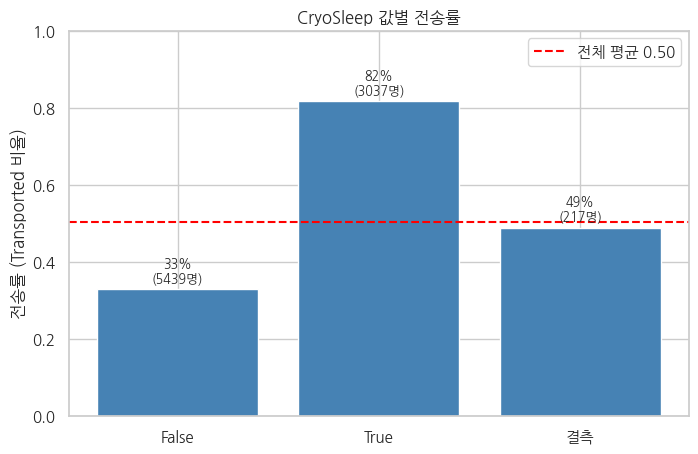

,mean,size
CryoSleep,,
False,0.328921,5439
True,0.817583,3037
NaN,0.488479,217


In [8]:
# CryoSleep 값(True/False/결측)별 전송률을 그려본다
표_cryo = 전송률_그래프("CryoSleep")
표_cryo

**이 그림으로 알게 된 것**  

- 냉동수면을 한 사람(True)은 전송률이 약 **82%** 로, 안 한 사람(False) 약  
  **33%** 보다 훨씬 높다. 전체 평균 50% 와 비교하면 위아래로 크게 벌어진다.  
- 즉 CryoSleep 은 전송 여부를 아주 강하게 가르는 변수다. 내 가설이 맞았다.  
- 왜 그럴까 생각해보면, 냉동수면 중이면 깨어 활동하거나 돈을 쓸 수 없으니,  
  나중에 볼 "지출이 0인 사람" 과 같은 사람을 가리킬 가능성이 크다. (이 연결은 지출 변수에서 다시 확인한다.)  
- 결측(nan)도 217명 있는데, 이건 나중에 전처리에서 어떻게 채울지 정한다.  

### 5-2. 지출 (편의시설에서 쓴 돈) - 분포에 속지 않기

다음은 편의시설 지출이다. 사실 처음에 지출 컬럼들을 그냥 보면 **0인 사람이  
압도적으로 많아서** "이건 별 의미 없는 변수겠네" 하고 넘기기 쉽다. 나도 처음엔 그렇게 생각했다.  
그런데 이게 함정이었다.  

핵심은 "값이 어떻게 퍼져 있나(분포)" 가 아니라 **"값에 따라 전송률이 달라지나(분별력)"** 다.  
그래서 지출 5개를 합친 `TotalSpend` 라는 파생변수를 새로 만들고, "한 푼이라도 썼나 / 안 썼나" 로  
전송률을 비교해본다. 이게 이 노트북에서 내가 처음 만드는 파생변수다.  

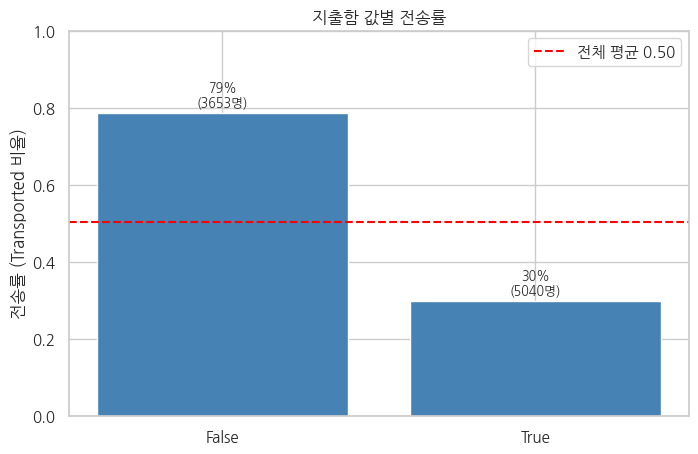

,mean,size
지출함,,
False,0.786477,3653
True,0.298611,5040


In [9]:
# 5개 편의시설 지출 컬럼
지출컬럼 = ["RoomService", "FoodCourt", "ShoppingMall", "Spa", "VRDeck"]

# 파생변수1) TotalSpend = 5개 지출의 합.
# (.sum 은 결측 NaN 을 일단 0 으로 보고 더한다. 결측의 정확한 처리는 전처리 단계에서 다시 한다)
train["TotalSpend"] = train[지출컬럼].sum(axis=1)

# 파생변수2) 지출함 = 돈을 한 푼이라도 썼는지 (True/False). 이걸로 전송률을 본다.
# 이건 EDA 로 신호를 확인하려는 임시 컬럼이고, 전처리에서 train/test 함께 깔끔히 다시 만든다.
train["지출함"] = train["TotalSpend"] > 0

# 돈을 안 쓴 사람 vs 쓴 사람의 전송률 비교
표_지출 = 전송률_그래프("지출함")
표_지출

**이 그림으로 알게 된 것**  

- 돈을 한 푼도 **안 쓴 사람(False)** 은 전송률이 약 **79%**, **쓴 사람(True)**  
  은 약 **30%** 다. 거의 50%p 차이로, 이 데이터에서 가장 강한 신호 중 하나다.  
- "0이 많아서 의미 없다" 는 내 처음 생각이 완전히 틀렸다. 값이 한쪽(0)에  
  몰려 있어도, **그 값으로 두 집단의 운명이 갈리면 그 변수는 황금**이다.  
- 그리고 이건 CryoSleep 과 이어진다. 냉동수면 중이면 객실에 갇혀 돈을 못 쓰니  
  지출이 0이고, 그래서 "냉동수면(82% 전송)" 과 "지출 0(79% 전송)" 이 같은 방향을 가리킨다.  
  개요가 준 힌트가 데이터로 확인된 셈이다.  

그럼 한 발 더 들어가서, **돈을 쓴 사람들 중에서는 "많이 쓸수록" 전송률이 더 달라질까?** 라는 가설도 확인해본다. 금액을 구간으로 나눠서 본다.  

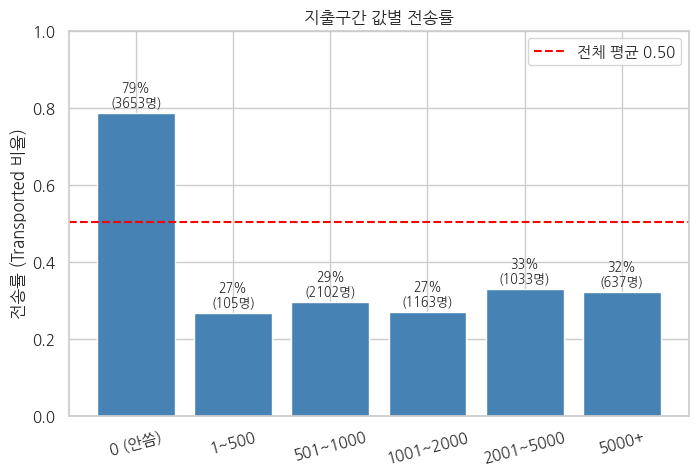

,mean,size
지출구간,,
0 (안씀),0.786477,3653
1~500,0.266667,105
501~1000,0.294481,2102
1001~2000,0.269132,1163
2001~5000,0.329138,1033
5000+,0.321821,637


In [10]:
# 가설 확인) 금액 크기 자체도 의미가 있을까? -> TotalSpend 를 구간으로 나눠 전송률을 본다
def 지출구간(x):
    if x == 0:        return "0 (안씀)"
    elif x <= 500:    return "1~500"
    elif x <= 1000:   return "501~1000"
    elif x <= 2000:   return "1001~2000"
    elif x <= 5000:   return "2001~5000"
    else:             return "5000+"

# 구간이 막대에서 순서대로 나오게 ordered 카테고리로 만든다
순서 = ["0 (안씀)", "1~500", "501~1000", "1001~2000", "2001~5000", "5000+"]
train["지출구간"] = pd.Categorical(train["TotalSpend"].apply(지출구간),
                                 categories=순서, ordered=True)

# 라벨이 길어서 살짝 회전시켜 그린다
표_구간 = 전송률_그래프("지출구간", 회전=15)
표_구간

**이 그림으로 알게 된 것 (가설은 틀렸다)**  

- 전송률이 갈리는 건 **딱 "0이냐 아니냐" 절벽 하나뿐**이다. 일단 돈을 쓰기 시작하면(1~500 이든 5000+ 든)  
  전송률은 26~33% 사이에서 비슷하게 평평하다.  
- 즉 "많이 쓸수록 전송률이 더 달라질 것" 이라는 내 가설은 데이터가 "아니오" 라고 답했다.  
  금액을 잘게 나눠봐야 별 이득이 없다는 뜻이다.  
- 그래서 전처리에서는 복잡한 금액 구간 대신, **"지출 0 여부" 라는 단순한 깃발 하나**만 만들면 충분하다는 걸 데이터로 확인했다.  
  (가설을 세우고 -> 데이터로 검증 -> 기각. 이런 실패한 가설도 분석의 일부라 남겨둔다.)  

### 5-3. Cabin 쪼개기 -> Deck (갑판)

앞 2절에서 봤듯 `Cabin` 은 `deck/num/side` 정보 3개가 한 칸에 붙어 있고,  
통째로 두면 고유값이 6560개라 모델이 쓸 수 없다.  
개요 힌트대로 쪼개서 `Deck`(갑판)별 전송률을 본다.  
이건 baseline 도 한 작업인데, 실제로 신호가 있는지 직접 확인한다.  

Cabin 통째 고유값: 6560 -> Deck 고유값: 8


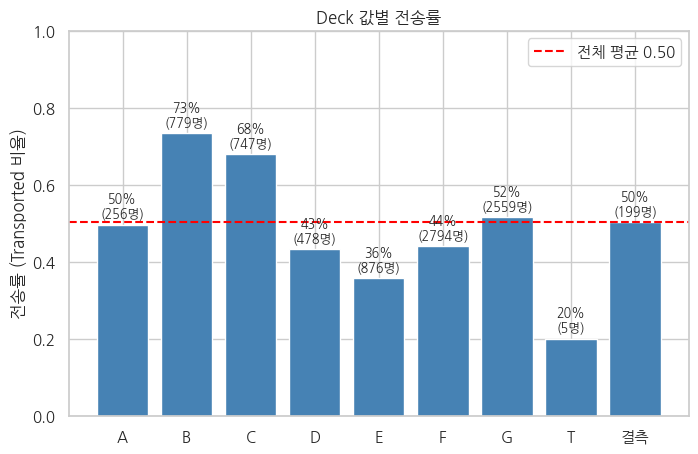

,mean,size
Deck,,
A,0.496094,256
B,0.734275,779
C,0.680054,747
D,0.433054,478
E,0.357306,876
F,0.439871,2794
G,0.516217,2559
T,0.200000,5
NaN,0.502513,199


In [11]:
# Cabin 을 deck / num / side 세 칸으로 쪼갠다 (개요가 알려준 형식)
# 역시 EDA 확인용. 전처리에서 train/test 함께 다시 깔끔히 만든다.
train[["Deck", "Cabin_num", "Side"]] = train["Cabin"].str.split("/", expand=True)

# 쪼개니까 고유값이 확 줄어서 "배울 만한 덩어리" 가 된다
print("Cabin 통째 고유값:", train["Cabin"].nunique(), "-> Deck 고유값:", train["Deck"].nunique())

표_deck = 전송률_그래프("Deck")
표_deck

**이 그림으로 알게 된 것**  

- 갑판마다 전송률이 확 다르다. **B(73%), C(68%)** 갑판은 높고, **E(36%)** 갑판은 낮다.  
  같은 배 안인데도 어느 갑판이냐로 운명이 갈렸다.  
- `Cabin` 통째로는 6560개 고유값이라 못 쓰던 게, `Deck` 으로 쪼개니 8개로 줄어
  "갑판 B 는 잘 전송" 같은 패턴이 드러났다. 쪼개기의 효과다.  
- `T` 갑판은 전송률이 낮아 보이지만 5명뿐이라 신뢰하기 어렵다. (표본이 작으면 비율이 출렁이니 조심한다.)  
  결측도 있는데 전처리에서 채운다.  

### 5-4. PassengerId 쪼개기 -> 그룹 / 혼자 (baseline 이 버린 신호)

baseline 은 `PassengerId` 를 그냥 버렸다. 그런데 개요에 `gggg_pp` 에서  
`gggg` 가 함께 여행하는 그룹이라고 했으니, 그룹을 뽑으면 "혼자 왔는지 일행이 있는지" 를 알 수 있다.  
baseline 이 놓친 이 신호가 진짜 있는지 확인한다.  
내가 채우려는 baseline의 부족한 점 중 하나다.  

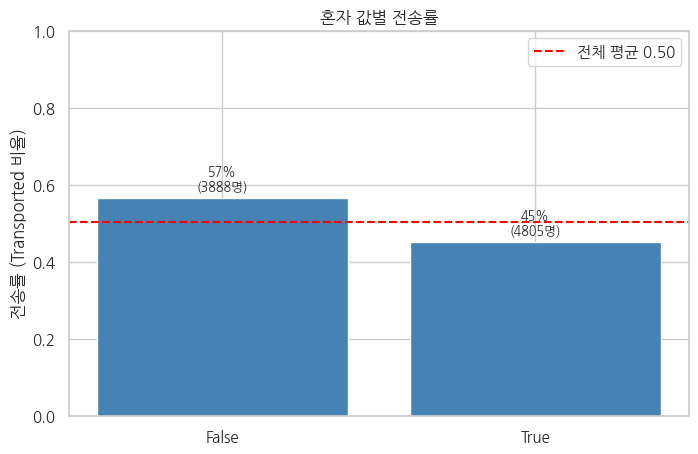

,mean,size
혼자,,
False,0.566872,3888
True,0.452445,4805


In [12]:
# PassengerId 의 gggg_pp 에서 앞부분(gggg)이 그룹. 같은 그룹은 함께 여행한 일행이다.
train["Group"] = train["PassengerId"].str.split("_").str[0]
# 그룹별 인원수를 세서 각 사람의 그룹 크기로 붙인다
train["GroupSize"] = train.groupby("Group")["PassengerId"].transform("size")
# 혼자 여행했나 (그룹에 자기 혼자뿐이면 True)
train["혼자"] = train["GroupSize"] == 1

표_혼자 = 전송률_그래프("혼자")
표_혼자

**이 그림으로 알게 된 것**  

- **혼자 온 사람(True)** 은 전송률 약 **45%**, **일행이 있는 사람(False)** 은  
  약 **57%** 다. 일행이 있으면 더 많이 전송됐다.  
- baseline 은 `PassengerId` 를 버려서 이 신호를 통째로 놓쳤다. 나는 이걸 살려서 쓸 거다.  

좀 더 자세히, 그룹 크기별로도 전송률을 본다.  

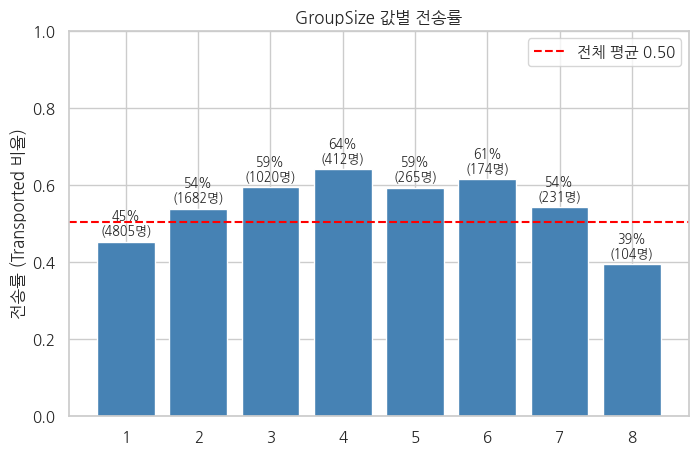

,mean,size
GroupSize,,
1,0.452445,4805
2,0.538050,1682
3,0.593137,1020
4,0.640777,412
5,0.592453,265
6,0.614943,174
7,0.541126,231
8,0.394231,104


In [13]:
# 그룹 크기(1명 ~ 8명)별 전송률
표_크기 = 전송률_그래프("GroupSize")
표_크기

**이 그림으로 알게 된 것**  

- 혼자(1명)일 때 45% 로 가장 낮고, 2~6명 그룹은 54~64% 로 더 높다.  
  즉 대체로 일행이 있을수록 전송률이 높다.  
- 7~8명은 다시 낮아 보이지만 인원이 104~231명으로 적은 편이라 끝쪽 값은 조심해서 본다.  
- 결론: 전처리에서 `GroupSize` 와 `혼자` 를 파생변수로 만들어 쓸 만하다. (`PassengerId` 를 버린 baseline 대비 내가 챙기는 부분이다.)  

### 5-5. 나머지 범주형 변수들 (HomePlanet / Side / Destination / VIP)

여기서부터는 신호가 좀 약하거나 보조적인 범주형 변수들을 같은 함수로 한 번에 본다. 앞에서 만든 `전송률_그래프` 가 있으니 한 줄씩이면 된다.  

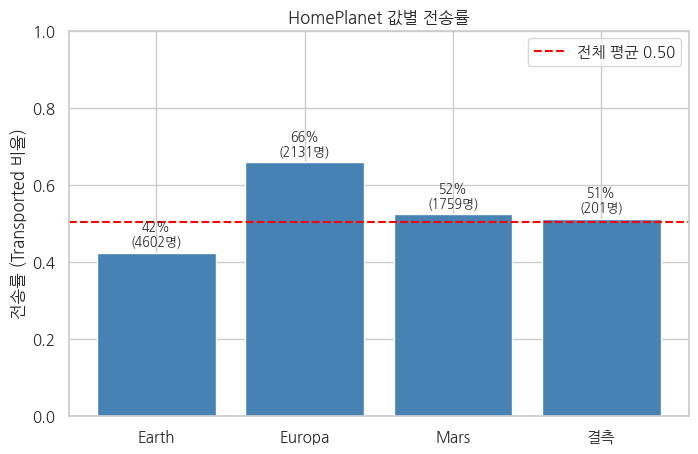

,mean,size
HomePlanet,,
Earth,0.423946,4602
Europa,0.658846,2131
Mars,0.523024,1759
NaN,0.512438,201


In [14]:
# 출발 행성별 전송률
표_home = 전송률_그래프("HomePlanet")
표_home

**HomePlanet** : Europa 출신이 66% 로 가장 높고, Earth 출신이 42% 로 가장 낮다 (Mars 는 52%).  
출발 행성에 따라 전송률이 꽤 갈리는, 쓸 만한 신호다.  

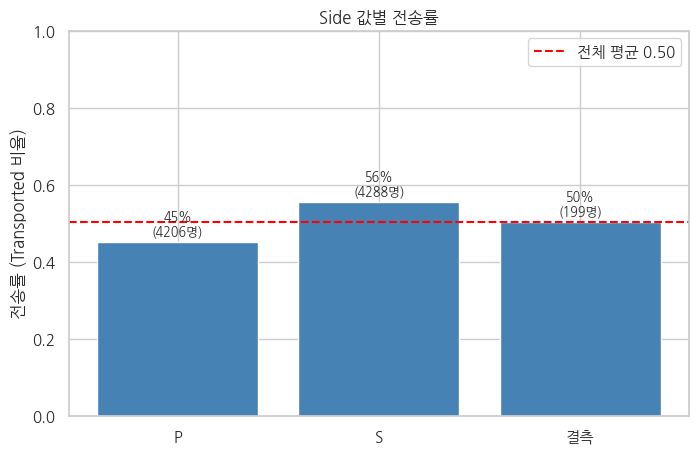

,mean,size
Side,,
P,0.451260,4206
S,0.555037,4288
NaN,0.502513,199


In [15]:
# Cabin 에서 쪼갠 Side(좌현 P / 우현 S)별 전송률
표_side = 전송률_그래프("Side")
표_side

**Side** : 우현(S)이 56%, 좌현(P)이 45% 로 약 10%p 차이가 난다.  
배의 어느 쪽에 탔느냐로도 갈리는데, 이상 현상이 한쪽으로 쏠렸던 것처럼 보인다.  

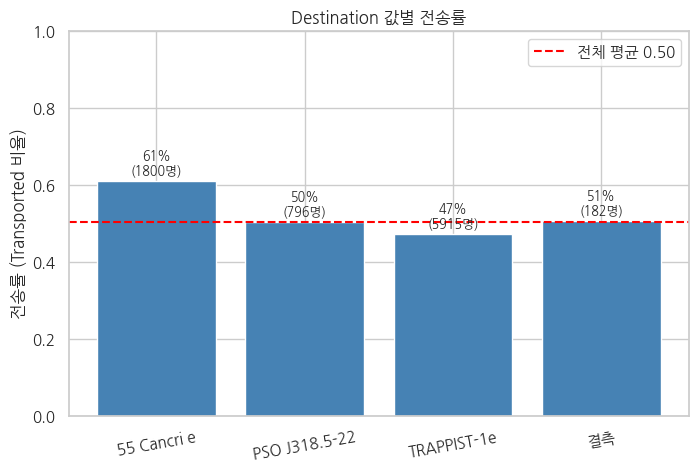

,mean,size
Destination,,
55 Cancri e,0.610000,1800
PSO J318.5-22,0.503769,796
TRAPPIST-1e,0.471175,5915
NaN,0.505495,182


In [16]:
# 목적지 행성별 전송률
표_dest = 전송률_그래프("Destination", 회전=10)
표_dest

**Destination** : 55 Cancri e 행성으로 가는 사람이 61% 로 좀 높고,  
TRAPPIST-1e 가 47% 로 좀 낮다. 차이가 크진 않지만 약한 신호는 있다.  

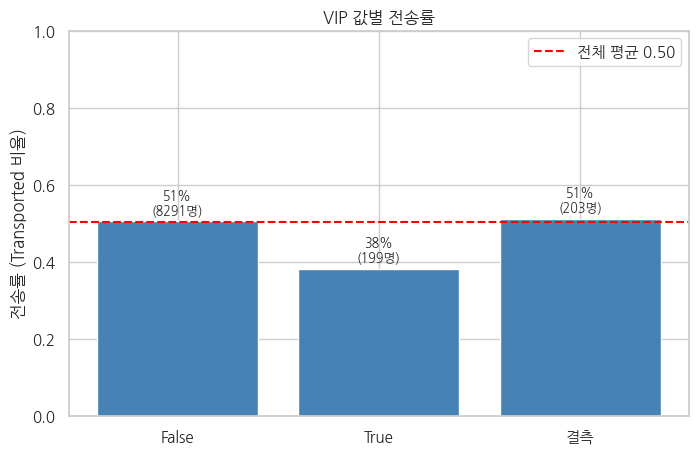

,mean,size
VIP,,
False,0.506332,8291
True,0.381910,199
NaN,0.512315,203


In [17]:
# VIP 여부별 전송률
표_vip = 전송률_그래프("VIP")
표_vip

**VIP** : VIP(True)가 오히려 38% 로 낮다. 다만 VIP 는 199명뿐이라 표본이 작아서,  
"그런 경향이 있다" 정도로만 받아들이고 과신하지 않는게 좋을것 같다.  

정리하면 이 4개는 CryoSleep/지출/Deck/Group 만큼 세진 않지만, HomePlanet 과 Side 는 꽤 쓸 만하고  
Destination/VIP 는 약한 보조 신호 정도로 알고 있는게 좋을것 같다.  

### 5-6. Age (나이) - 수치형 변수 보기

Age 는 지금까지의 범주형(True/False, 갑판 등) 과 달리 0~79 까지 이어지는  
**수치형** 변수다. 그래서 두 가지 방법으로 보는게 좋을것 같다.  

1. **분포 비교** : 전송된 사람과 안 된 사람의 나이 분포를 겹쳐 그려서,    
   어느 나이대에서 둘이 갈리는지 본다. (참고자료로 본 타이타닉 튜토리얼에서 쓰던 방식이다.)  
2. **구간으로 나눠 전송률** : 나이를 몇 개 구간으로 묶어서, 내가 계속 쓰던  
   "조건별 전송률" 렌즈로 다시 본다.  

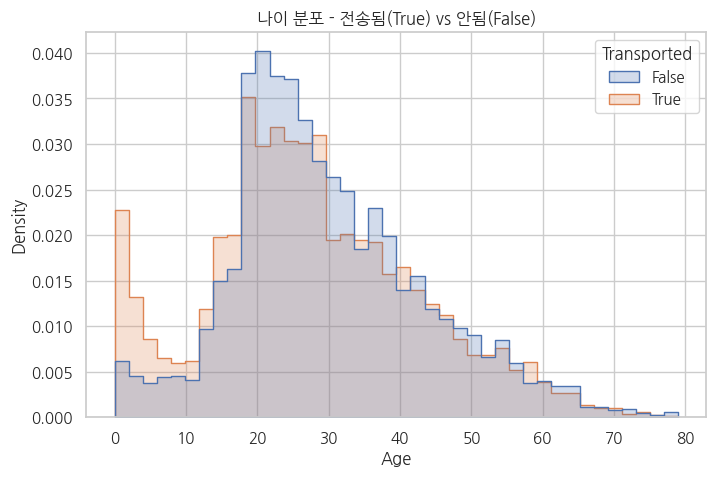

In [18]:
# 방법1) 전송됨(True)/안됨(False) 별로 나이 분포를 겹쳐 그린다.
# stat="density", common_norm=False -> 두 집단 인원수가 달라도 모양을 공평하게 비교
plt.figure()
sns.histplot(data=train, x="Age", hue="Transported", bins=40,
             element="step", stat="density", common_norm=False)
plt.title("나이 분포 - 전송됨(True) vs 안됨(False)")
plt.show()

**이 그림으로 알게 된 것 (분포 비교)**  

- 대부분의 나이대에서는 두 분포가 거의 겹친다. 즉 나이 하나만으로는 크게 갈리지 않는다.  
- 그런데 **아주 어린 아이(대략 0~12세) 구간에서는 전송됨(True) 쪽이 더 많다.** 어린이가 더 많이 전송된 것으로 보인다.  

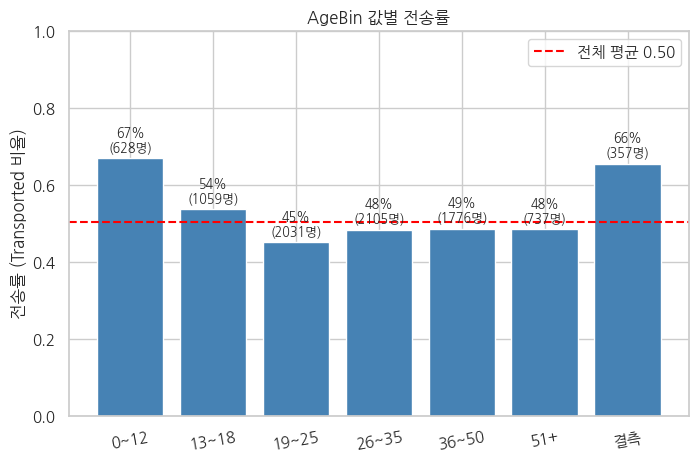

,mean,size
AgeBin,,
0~12,0.668790,628
13~18,0.537299,1059
19~25,0.451502,2031
26~35,0.483135,2105
36~50,0.486486,1776
51+,0.484396,737
NaN,0.655462,357


In [19]:
# 방법2) 나이를 구간으로 나눠 전송률을 본다 (내가 계속 쓰던 렌즈)
구간 = [0, 12, 18, 25, 35, 50, 200]
라벨 = ["0~12", "13~18", "19~25", "26~35", "36~50", "51+"]
train["AgeBin"] = pd.cut(train["Age"], bins=구간, labels=라벨, right=True)

표_age = 전송률_그래프("AgeBin", 회전=10)
표_age

**이 그림으로 알게 된 것 (구간별 전송률)**  

- **0~12세 어린이가 67%** 로 전송률이 확 높다. 반대로 **19~25세 청년이 45%**  
  로 가장 낮고, 그 위 나이대는 48% 안팎으로 평평하다.  
- 분포 비교에서 본 "어린이가 더 전송됨" 이 숫자로 확인됐다.  
- 흥미로운 점: 처음에 나이를 그냥 분포로만 봤을 땐 "별 의미 없네" 싶었는데,  
  전송률로 보니 **어린이 신호**가 드러났다. 또 한 번 "분포보다 분별력" 이  
  맞았다. 그래서 Age 는 약하지만, 특히 어린이 여부로 쓸 만한 신호다.  
- 결측이 179명 있어서 전처리에서 채운다 (전체 평균 50% 근처라 한쪽으로  
  치우치진 않았다).  

### 5-7. 결측치 한눈에 보기 (missingno) - EDA 마무리

변수별로 결측을 따로 봤는데, 마지막으로 **어느 컬럼이 얼마나 비어 있나**를  
한 장에 정리한다. 이러면 다음 단계인 전처리에서 "무엇을 어떻게 채울까" 로  
바로 이어진다.  

참고로 내가 본 참고자료인 이유한 님의 캐글 타이타닉 튜토리얼 (https://kaggle-kr.tistory.com/17) 도  
맨 앞 "Null data check" 단계에서  
`missingno` 의 `matrix` / `bar` 차트로 결측을 시각화하며 시작한다.  
나도 같은 방식을 가져왔다. (복습용으로 출처를 적어둔다.)  

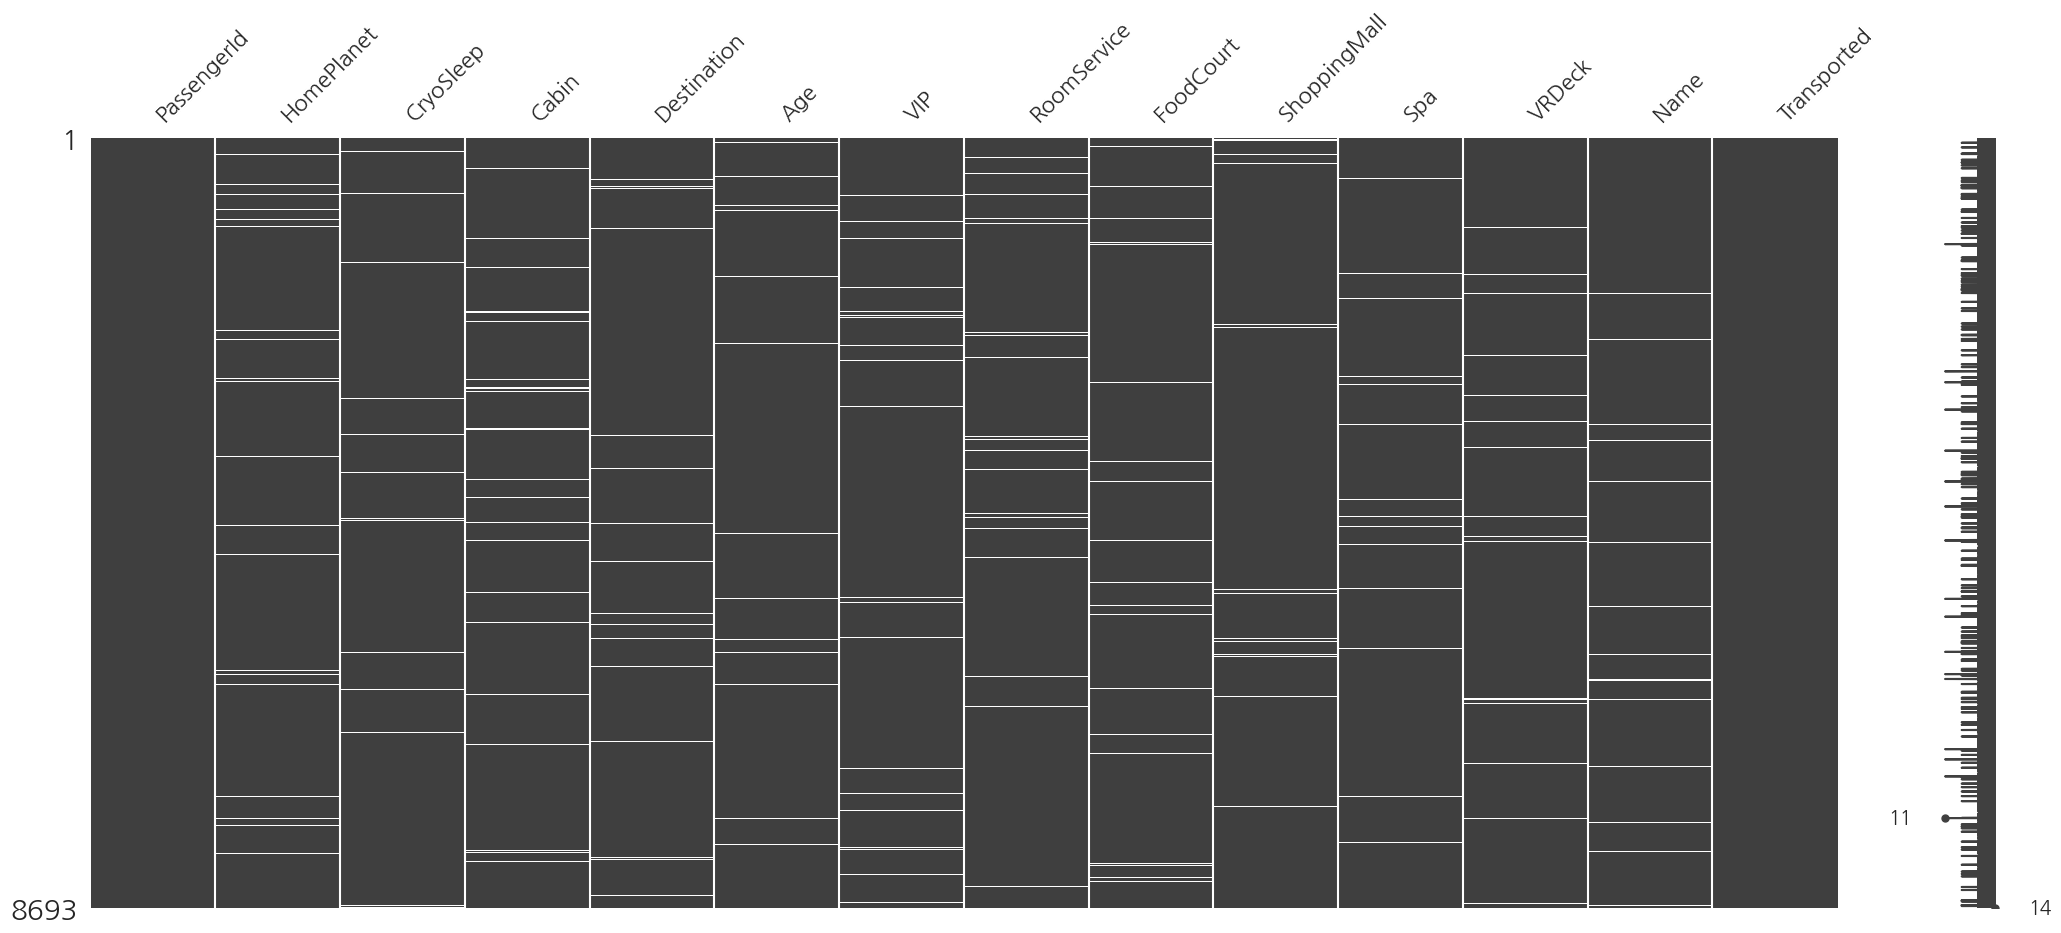

In [20]:
import missingno as msno   # 결측치 시각화 전용 라이브러리

# EDA 중에 파생 컬럼을 여럿 붙였으니, 결측은 원래 컬럼 14개만 깔끔하게 본다
원본컬럼 = ["PassengerId", "HomePlanet", "CryoSleep", "Cabin", "Destination",
          "Age", "VIP", "RoomService", "FoodCourt", "ShoppingMall",
          "Spa", "VRDeck", "Name", "Transported"]

# matrix: 행을 죽 늘어놓고 빈칸(흰 줄)이 어디에 있는지 패턴으로 보여준다
msno.matrix(train[원본컬럼])
plt.show()

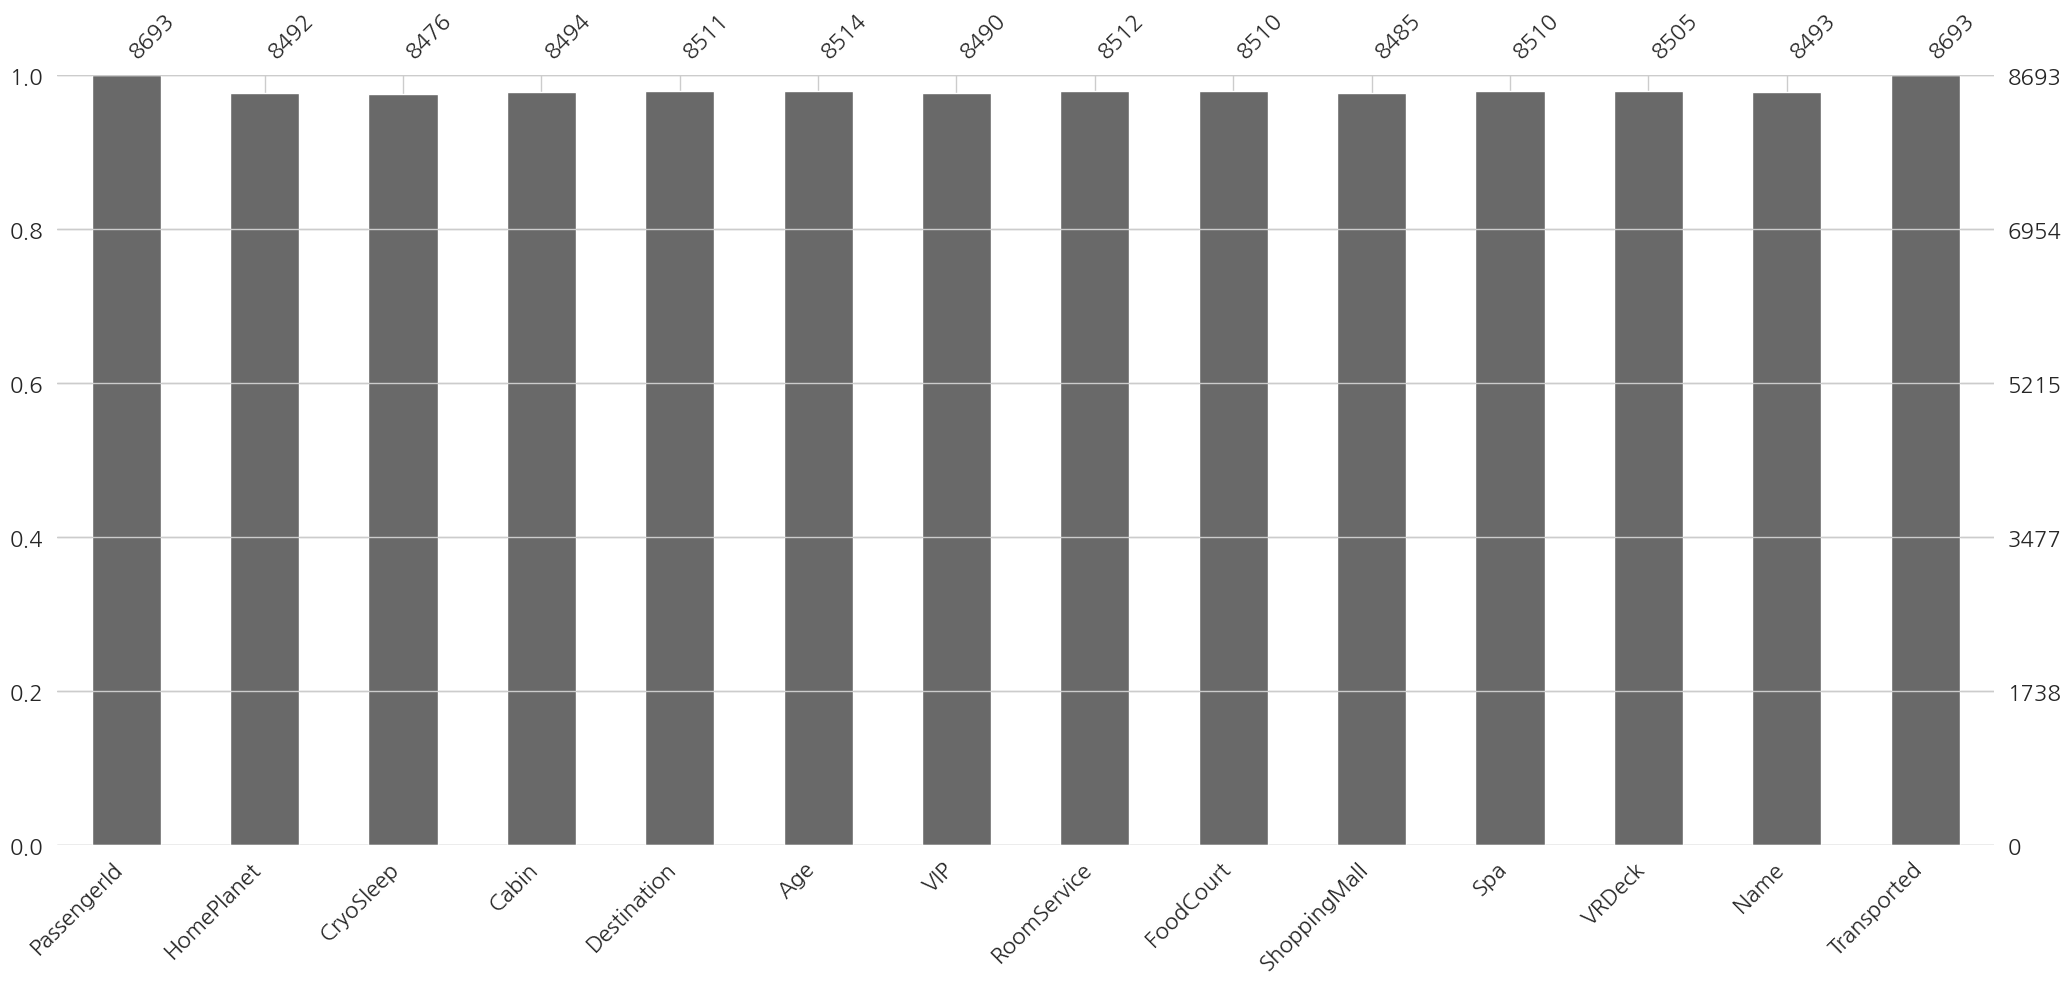

PassengerId       0
HomePlanet      201
CryoSleep       217
Cabin           199
Destination     182
Age             179
VIP             203
RoomService     181
FoodCourt       183
ShoppingMall    208
Spa             183
VRDeck          188
Name            200
Transported       0
dtype: int64


In [21]:
# bar: 컬럼별로 '값이 채워진 비율' 을 막대로 보여준다 (짧을수록 결측이 많다)
msno.bar(train[원본컬럼])
plt.show()

# 숫자로도 한 번 더 확인
print(train[원본컬럼].isnull().sum())

**이 그림으로 알게 된 것**  

- `PassengerId` 와 정답 `Transported` 빼고는, **거의 모든 컬럼에 결측이 조금씩  
  (약 2%, 179~217개)** 있다. 특정 한 컬럼만 크게 비는 게 아니라 **골고루 흩어져** 있다.  
- 이건 원조 타이타닉(Cabin 이 77% 나 비어서 거의 버려야 했던 것) 과 다른 점이다.  
  여기서는 어느 컬럼도 통째로 버릴 만큼 비어 있지 않으니, **버리기 보다 컬럼마다 알맞게 채우는(보간) 게 핵심**이다.  
- 그래서 다음 전처리 단계에서는 그냥 0 으로 다 메운 baseline 과 달리,  
  CryoSleep(자면 지출 0) 같은 도메인 규칙을 써서 똑똑하게 채울 거다.  

이걸로 EDA 를 마친다. 다음은 여기서 찾은 신호와 결측 패턴을 바탕으로  
전처리 / 파생변수를 만든다.  

## 6. 전처리를 위한 추가 분석 - "어떻게 채울지" 고민해보기

EDA 로 신호는 찾았다. 그런데 결측치를 어떻게 채울지 정하려면,  
baseline 처럼 무지성으로 0 / 최빈값으로 때우기 전에 **한 번 더 분석**해서 고민해 보는게 좋겠다.  
이 부분이 이번 프로젝트에서 내가 가장 많이 배운 곳이라 과정을 그대로 남겨본다.  

확인하고 싶은 건 두 가지다.  
1. CryoSleep(냉동수면) 과 지출이 정말 맞물려 있나? -> CryoSleep 결측을 지출로 채울 수 있을까?  
2. 같은 그룹(일행)은 어떤 값이 같나? -> 그 값의 결측을 일행 값으로 채울 수 있을까?  

### 6-1. CryoSleep 과 지출의 관계 (교차표 heatmap)

"냉동수면 중이면 객실에 갇혀 돈을 못 쓴다" 는 개요 힌트가 데이터에서도 맞는지, CryoSleep 과 "지출 0 여부" 를 교차표로 본다.  

지출0        False  True 
CryoSleep              
False       4921    518
True           0   3037


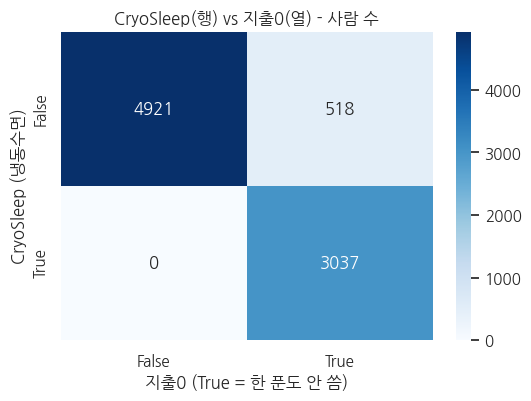

In [22]:
# 지출을 한 푼도 안 썼는지 (5-2 에서 만든 TotalSpend 사용)
train["지출0"] = train["TotalSpend"] == 0

# CryoSleep(행) 과 지출0(열) 의 사람 수 교차표
교차 = pd.crosstab(train["CryoSleep"], train["지출0"])
print(교차)

# 교차표를 heatmap 으로 (숫자가 클수록 진하게)
plt.figure(figsize=(6, 4))
sns.heatmap(교차, annot=True, fmt="d", cmap="Blues")
plt.title("CryoSleep(행) vs 지출0(열) - 사람 수")
plt.ylabel("CryoSleep (냉동수면)")
plt.xlabel("지출0 (True = 한 푼도 안 씀)")
plt.show()

**이 표로 알게 된 것 (CryoSleep 보간 근거)**  

- CryoSleep 이 **True(냉동수면)** 인 사람은 전부 "지출 0" 칸에 있고, "돈 씀"  
  칸에는 0명이다. 즉 **냉동수면자는 100% 돈을 안 썼다.** 개요 힌트가 맞다.  
- 그런데 반대로, CryoSleep 이 **False(깨어있음)** 인데도 돈을 0원 쓴 사람이  
  꽤 있다. (깨어 있어도 안 쓸 수 있으니까.)  
- 여기서 중요한 비대칭이 나온다.  
  - "지출 > 0" 이면 -> CryoSleep 은 **반드시 False** (확실하다. 자는 사람은  
    절대 돈을 못 쓰니까)  
  - "지출 == 0" 이면 -> CryoSleep 은 **아마 True** (확실하진 않지만 0원인  
    사람의 대부분이 냉동수면자다)  
- 그래서 CryoSleep 결측은 이 규칙으로 채운다: **지출이 있으면 False, 없으면  
  True.** baseline 처럼 그냥 0 으로 안 채우고 근거를 만든 것이다.  

### 6-2. 같은 그룹은 어떤 값이 같나 (그룹 보간 가능성)

다음으로, 같은 그룹(일행)끼리 값이 얼마나 일치하는지 본다. 100% 같다면 그 컬럼의 결측은 일행의 값으로 정확히 채울 수 있다.  

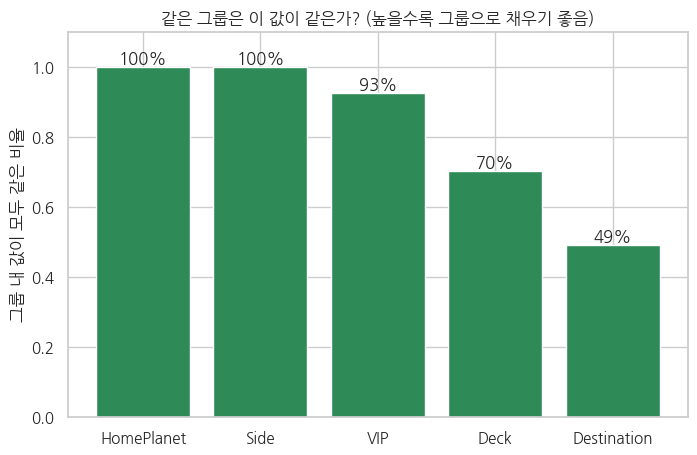

HomePlanet     1.000000
Side           1.000000
VIP            0.925585
Deck           0.701841
Destination    0.492210
dtype: float64

In [23]:
# 2명 이상인 그룹만 대상으로, 컬럼별 '그룹 내 값이 전부 같은 비율' 을 구한다
인원 = train.groupby("Group").size()
여럿그룹 = 인원[인원 > 1].index            # 일행이 있는 그룹

일치율 = {}
for col in ["HomePlanet", "Side", "VIP", "Deck", "Destination"]:
    # 결측은 빼고, 그룹별로 그 컬럼의 값 종류 수(nunique)를 센다. 1이면 전부 같음.
    g = train.dropna(subset=[col]).groupby("Group")[col].nunique()
    g = g[g.index.isin(여럿그룹)]
    일치율[col] = (g == 1).mean()

일치율_s = pd.Series(일치율).sort_values(ascending=False)

plt.figure()
막대 = plt.bar(일치율_s.index, 일치율_s.values, color="seagreen")
for b, v in zip(막대, 일치율_s.values):
    plt.text(b.get_x() + b.get_width()/2, v + 0.01, f"{v*100:.0f}%", ha="center")
plt.ylim(0, 1.1)
plt.ylabel("그룹 내 값이 모두 같은 비율")
plt.title("같은 그룹은 이 값이 같은가? (높을수록 그룹으로 채우기 좋음)")
plt.show()
일치율_s

**이 그림으로 알게 된 것 (그룹 보간 근거)**  

- **HomePlanet 과 Side 는 그룹 내 100% 일치**한다. 같은 일행은 출발 행성도,  
  객실 좌우(P/S)도 무조건 같다. -> 이 둘의 결측은 **일행의 값으로 채우면  
  정확**하다.  
- VIP(93%), Deck(70%) 도 대체로 같아서 그룹값을 힌트로 쓸 만하다.  
- Destination 은 49% 라 그룹으로는 못 채운다. -> 이건 그냥 최빈값으로 채운다.  
- 이 분석이 없었으면 HomePlanet 도 그냥 최빈값으로 대충 때웠을 텐데, 분석 덕분에 더 정확한 보간법을 찾았다.  

### 6-3. 수치형 변수 상관관계 (heatmap)

마지막으로 수치형 변수들끼리, 그리고 정답과의 상관관계를 heatmap 으로 한 번 정리한다.  

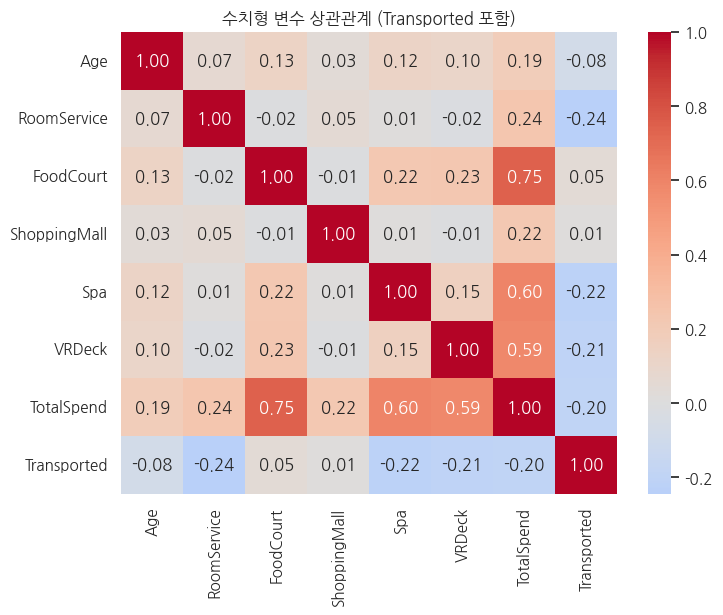

In [24]:
# 수치형 + 정답(0/1) 의 상관계수 heatmap
수치 = ["Age", "RoomService", "FoodCourt", "ShoppingMall", "Spa", "VRDeck", "TotalSpend"]
상관표 = train[수치].copy()
상관표["Transported"] = train["Transported"].astype(int)   # 상관 계산 위해 0/1 로

plt.figure(figsize=(8, 6))
sns.heatmap(상관표.corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("수치형 변수 상관관계 (Transported 포함)")
plt.show()

**이 heatmap 으로 알게 된 것**  

- RoomService(-0.25), Spa(-0.22), VRDeck(-0.21) 이 Transported 와 음의 상관이 가장 크다. 돈을 쓸수록 전송이 덜 됐다는 EDA 결론과 같은 방향이다.  
- FoodCourt, ShoppingMall 은 상관이 거의 0 이라 약하다. (앞에서 지출별 격차를 봤을 때도 이 둘이 작았다.)  
- Age 도 -0.08 로 약하다.  
- 한 가지 주의:  
  이 상관계수는 "직선 관계" 만 잡는다. 지출의 진짜 신호는  
  "0 이냐 아니냐" 라는 절벽(직선 아님)이라, 상관계수 -0.2 는 실제 신호보다  
  작게 나온 값이다. 그래서 숫자 그대로보다 EDA 의 전송률 그래프가 더 정확하다.  

## 7. 전처리 / 파생변수 만들기

이제 EDA 와 6절 분석에서 정한 설계를 코드로 옮긴다. 핵심 원칙 두 가지를 지킨다.  

1. **train 과 test 를 합쳐서** 처리한다. 그래야 그룹(일행)이 두 곳에 흩어져 있어도  
   GroupSize 를 정확히 세고, 일행 값으로 보간할 수 있다. (정답 Transported 는 빼고 합치니 누수는 없다.)  
2. **중앙값 / 최빈값 같은 통계 보간값은 train 부분에서만** 계산한다.  
   test 를 훔쳐보지 않기 위해서다(위 용어 메모의 "누수" 방지).  

그리고 이 전처리 과정을 **함수 하나(`전처리`)로 묶는다.** 왜냐하면 똑같은 전처리를  
train 에도 test 에도 해야 하는데, 만약 과정을 두 번 따로 적어두면  
나중에 "파생변수 하나 더 추가하자" 같은 수정을 할 때 두 군데를 다 고쳐야 하고,  
한 곳만 고치고 깜빡하면 train 과 test 가 서로 달라져서 모델이 고장난다.  
함수 한 장에 적어두면(요리 레시피 카드처럼) 고칠 일이 생겨도 그 한 곳만 고치면 되고 실수도 없다.  

In [25]:
# EDA 하면서 train 에 임시 컬럼을 많이 붙였으니, 전처리는 csv 에서 새로 깨끗하게 읽어서 한다
train_raw = pd.read_csv(DATA + "train.csv")
test_raw = pd.read_csv(DATA + "test.csv")

def 전처리(train_df, test_df):
    # 정답(0/1)과 제출용 id 를 먼저 빼둔다
    y = train_df["Transported"].astype(int)
    test_ids = test_df["PassengerId"].copy()

    # train/test 를 세로로 합친다 (정답은 빼고). 어디서 왔는지 source 로 표시.
    tr = train_df.drop(columns=["Transported"]).copy(); tr["source"] = "train"
    te = test_df.copy();                                te["source"] = "test"
    df = pd.concat([tr, te], ignore_index=True)

    # ---------- 파생변수 ----------
    # 그룹: PassengerId(gggg_pp)의 앞부분 gggg
    df["Group"] = df["PassengerId"].str.split("_").str[0]
    df["GroupSize"] = df.groupby("Group")["PassengerId"].transform("size")  # 합친 상태라 정확
    df["혼자"] = df["GroupSize"] == 1

    # Cabin 쪼개기: deck/num/side 중 deck 과 side 만 쓴다 (가운데 번호는 버리기로 함)
    cab = df["Cabin"].str.split("/", expand=True)
    df["Deck"] = cab[0]
    df["Side"] = cab[2]

    # 지출: 결측을 0 으로 먼저 채우고 합계/0여부 파생을 만든다
    지출컬럼 = ["RoomService", "FoodCourt", "ShoppingMall", "Spa", "VRDeck"]
    df[지출컬럼] = df[지출컬럼].fillna(0)
    df["TotalSpend"] = df[지출컬럼].sum(axis=1)
    df["지출0여부"] = df["TotalSpend"] == 0

    # ---------- 보간 ----------
    # CryoSleep: 지출 있으면 False, 없으면 True (근거는 6-1 교차표 분석)
    빈칸 = df["CryoSleep"].isna()
    df.loc[빈칸, "CryoSleep"] = (df.loc[빈칸, "TotalSpend"] == 0)

    # 그룹으로 채우기: 같은 일행의 값으로 (HomePlanet/Side 100%, Deck 70% 힌트)
    def 그룹값채우기(col):
        def f(s):
            m = s.mode()                                   # 그룹 안에서 가장 흔한 값
            return s.fillna(m.iloc[0]) if len(m) > 0 else s
        df[col] = df.groupby("Group")[col].transform(f)
    for col in ["HomePlanet", "Side", "Deck"]:
        그룹값채우기(col)

    # 그래도 남은 결측(그룹 전체가 비었거나 혼자인 경우)은 train 통계로 채운다
    is_train = df["source"] == "train"
    for col in ["HomePlanet", "Side", "Deck", "Destination"]:
        df[col] = df[col].fillna(df.loc[is_train, col].mode().iloc[0])   # train 최빈값
    df["VIP"] = df["VIP"].fillna(False)                                  # VIP 는 드무니 False
    df["Age"] = df["Age"].fillna(df.loc[is_train, "Age"].median())       # train 중앙값

    # 어린이 플래그 (Age 보간 후에 만든다)
    df["is_child"] = df["Age"] <= 12

    # ---------- 인코딩 ----------
    # bool 플래그 -> 0/1
    for c in ["CryoSleep", "VIP", "혼자", "지출0여부", "is_child"]:
        df[c] = df[c].astype(bool).astype(int)
    # 범주형 -> 원핫. 합친 상태에서 하니 train/test 컬럼이 자동으로 똑같아진다.
    df = pd.get_dummies(df, columns=["HomePlanet", "Destination", "Deck", "Side"])
    # 원핫으로 생긴 True/False 컬럼들도 0/1 로 바꾼다
    bool컬럼 = df.select_dtypes("bool").columns
    df[bool컬럼] = df[bool컬럼].astype(int)

    # ---------- 안 쓸 컬럼 버리고 train/test 다시 분리 ----------
    df = df.drop(columns=["PassengerId", "Name", "Cabin", "Group"])
    X_train = df[df["source"] == "train"].drop(columns=["source"]).reset_index(drop=True)
    X_test = df[df["source"] == "test"].drop(columns=["source"]).reset_index(drop=True)
    return X_train, y, X_test, test_ids

# 전처리 실행
X_train, y_train, X_test, test_ids = 전처리(train_raw, test_raw)
print("전처리 끝")
print("X_train shape:", X_train.shape, "/ X_test shape:", X_test.shape)

전처리 끝
X_train shape: (8693, 29) / X_test shape: (4277, 29)


전처리가 잘 됐는지 확인한다.  
(1) 결측이 0개인지  
(2) train/test 컬럼이 똑같은지  
(3) 모든 값이 숫자인지 셋을 점검한다.  
이게 어긋나면 모델에 제공되는 데이터 품질이 낮아질 것이다.  

In [26]:
# 1) 결측이 전부 사라졌나
print("X_train 결측 합:", int(X_train.isnull().sum().sum()))
print("X_test  결측 합:", int(X_test.isnull().sum().sum()))

# 2) train/test 컬럼이 완전히 같은가 (순서까지)
print("컬럼 동일?:", list(X_train.columns) == list(X_test.columns))

# 3) 숫자가 아닌(object) 컬럼이 남아있나
print("숫자 아닌 컬럼:", list(X_train.select_dtypes('object').columns))

print("\n최종 피처 개수:", X_train.shape[1])
print("피처 목록:", list(X_train.columns))

X_train 결측 합: 0
X_test  결측 합: 0
컬럼 동일?: True
숫자 아닌 컬럼: []

최종 피처 개수: 29
피처 목록: ['CryoSleep', 'Age', 'VIP', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'GroupSize', '혼자', 'TotalSpend', '지출0여부', 'is_child', 'HomePlanet_Earth', 'HomePlanet_Europa', 'HomePlanet_Mars', 'Destination_55 Cancri e', 'Destination_PSO J318.5-22', 'Destination_TRAPPIST-1e', 'Deck_A', 'Deck_B', 'Deck_C', 'Deck_D', 'Deck_E', 'Deck_F', 'Deck_G', 'Deck_T', 'Side_P', 'Side_S']


In [27]:
# 전처리 결과 맨 앞 3줄 (어떻게 바뀌었는지 눈으로 확인)
X_train.head(3)

,CryoSleep,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,GroupSize,혼자,TotalSpend,지출0여부,is_child,HomePlanet_Earth,HomePlanet_Europa,HomePlanet_Mars,Destination_55 Cancri e,Destination_PSO J318.5-22,Destination_TRAPPIST-1e,Deck_A,Deck_B,Deck_C,Deck_D,Deck_E,Deck_F,Deck_G,Deck_T,Side_P,Side_S
0,0,39.0,0,0.0,0.0,0.0,0.0,0.0,1,1,0.0,1,0,0,1,0,0,0,1,0,1,0,0,0,0,0,0,1,0
1,0,24.0,0,109.0,9.0,25.0,549.0,44.0,1,1,736.0,0,0,1,0,0,0,0,1,0,0,0,0,0,1,0,0,0,1
2,0,58.0,1,43.0,3576.0,0.0,6715.0,49.0,2,0,10383.0,0,0,0,1,0,0,0,1,1,0,0,0,0,0,0,0,0,1


**전처리 결과 정리**  

- 결측이 모두 0개가 됐고, train/test 컬럼이 완전히 일치하며, 모든 값이 숫자(0/1 또는 수치)로 바뀌었다. 이제 모델이 바로 먹을 수 있는 상태다.  
- baseline 과 다른 점: 무지성 `fillna(0)` 대신 근거 있는 보간을 했고,  
  `TotalSpend` / `지출0여부` / `GroupSize` / `혼자` / `is_child` 같은 파생변수를 새로 만들었다.  
  EDA 에서 찾은 신호를 모델이 쓸 수 있는 형태로 옮긴 것이다.  

## 8. 모델링 - 교차검증(CV)으로 모델 고르기

이제 전처리한 데이터로 모델을 학습시킨다.  
제출하기 전에 **교차검증(cross validation, CV)** 으로 점수를 미리 가늠한다.  

**교차검증이 뭐냐면**: train 을 5조각으로 나눠서, 4조각으로 학습하고 1조각으로  
채점하는 걸 조각을 바꿔가며 5번 반복한 뒤 평균낸다. 한 번만 나누면 우연에 흔들리는데,  
5번 돌려 평균내면 더 안정적인 점수가 나온다. 여기서는 `StratifiedKFold` 를 쓰는데,  
이건 **각 조각마다 정답(True/False) 비율을 똑같이 유지**해줘서 분류 문제에 알맞다.  

StratifiedKFold — 왜 조각마다 정답 비율이 유지되는지는  
일반 KFold는 데이터를 답을 안 보고 그냥 5조각으로 뚝뚝 자르는데,  
StratifiedKFold는 자르기 전에 답(Transported)을 먼저 보고
True인 사람들 더미 / False인 사람들 더미로 나눠서  
True 더미를 5등분, False 더미도 5등분  
각 조각 = (True 5등분 중 하나) + (False 5등분 중 하나) 를 합쳐서 만든다.  
-> 그래서 모든 조각이 자동으로 전체와 같은 True:False 비율을 갖게 한다.  
  
  
두 모델을 비교한다.  
- **RandomForest** : baseline 이 쓴 엔진 (여러 트리의 다수결)  
- **CatBoost** : 부스팅 계열 (앞 트리의 실수를 다음 트리가 보완하며 학습)  

In [28]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from catboost import CatBoostClassifier

# 5조각으로 나누되 조각마다 타겟 비율 유지, 섞어서 나눔
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 1) baseline 엔진: RandomForest
rf = RandomForestClassifier(n_estimators=400, random_state=42, n_jobs=-1)
rf_score = cross_val_score(rf, X_train, y_train, cv=cv, scoring="accuracy")
print(f"RandomForest CV 정확도: {rf_score.mean():.4f}  (+- {rf_score.std():.4f})")

# 2) 부스팅 엔진: CatBoost
cat = CatBoostClassifier(iterations=800, learning_rate=0.03, depth=6,
                         verbose=0, random_state=42)
cat_score = cross_val_score(cat, X_train, y_train, cv=cv, scoring="accuracy")
print(f"CatBoost     CV 정확도: {cat_score.mean():.4f}  (+- {cat_score.std():.4f})")

RandomForest CV 정확도: 0.7914  (+- 0.0054)


CatBoost     CV 정확도: 0.8116  (+- 0.0093)


**RandomForest 와 CatBoost 비교**  

- RandomForest 는 CV 약 **0.79** 로 목표 0.805 에 못 미친다.  
- CatBoost 는 CV 약 **0.81** 로 목표를 넘는다.  
- 같은 데이터인데 부스팅(CatBoost)이 더 높다. 부스팅은 앞 트리의 실수를 다음 트리가 보완하며 학습해서 더 정밀한데, 그게 실제로 확인됐다.  

**추가 실험: 여러 모델을 섞으면 더 오를까? (앙상블)**  

CatBoost 가 제일 좋았는데, 혹시 LightGBM, XGBoost 까지 섞으면 더 오를지 직접 해본다.  
방법은 **소프트 보팅** 인데, 세 모델이 각자 낸 예측 확률을 평균내서 결정하는 방식이다.  

In [29]:
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import VotingClassifier

# 비교용 두 부스팅 모델
lgb = LGBMClassifier(n_estimators=600, learning_rate=0.03, random_state=42, verbose=-1)
xgb = XGBClassifier(n_estimators=600, learning_rate=0.03, max_depth=5,
                    random_state=42, eval_metric="logloss", verbosity=0)

for 이름, m in [("LightGBM", lgb), ("XGBoost ", xgb)]:
    s = cross_val_score(m, X_train, y_train, cv=cv, scoring="accuracy")
    print(f"{이름} CV 정확도: {s.mean():.4f}")

# 소프트 보팅: CatBoost + LightGBM + XGBoost 의 예측 확률을 평균
vote = VotingClassifier(estimators=[("cat", cat), ("lgb", lgb), ("xgb", xgb)], voting="soft")
vote_score = cross_val_score(vote, X_train, y_train, cv=cv, scoring="accuracy")
print(f"앙상블(소프트보팅) CV 정확도: {vote_score.mean():.4f}")

LightGBM CV 정확도: 0.8034


XGBoost  CV 정확도: 0.8058


앙상블(소프트보팅) CV 정확도: 0.8087


**앙상블 실험 결과 (시도했지만 더 좋아지지 않았다)**  

- LightGBM 과 XGBoost 는 CatBoost 보다 살짝 낮다.  
- 셋을 섞은 앙상블도 CatBoost 단독보다 못하거나 비슷하다. 약한 모델 (LightGBM/XGBoost)이 평균을 끌어내린 탓이다.  
- 그래서 앙상블은 쓰지 않고, 최종 모델은 **CatBoost 단독**으로 정한다.  
  (더 좋아지지 않은 실험도 기록으로 남긴다 — 이런 시도와 실패도 분석의 일부이고, 왜 단독을 골랐는지 근거가 된다.)  

## 9. 최종 학습 -> 예측 -> 제출 파일 만들기

고른 CatBoost 를 **train 전체**로 다시 학습시키고(이제 조각낼 필요 없이 가진 정답 데이터를 다 쓴다), 정답이 가려진 test 를 예측해서 제출 파일을 만든다.  

In [30]:
# 최종 모델: CatBoost 를 train 전체로 학습
final_model = CatBoostClassifier(iterations=800, learning_rate=0.03, depth=6,
                                 verbose=0, random_state=42)
final_model.fit(X_train, y_train)

# test 예측 -> 제출은 True/False 형식이라 bool 로 바꾼다
pred = final_model.predict(X_test).astype(bool)

# 제출 파일: PassengerId, Transported 두 칸 (sample_submission 과 같은 형식)
submission = pd.DataFrame({"PassengerId": test_ids, "Transported": pred})
submission.to_csv("submission.csv", index=False)
print("submission.csv 저장 완료:", submission.shape)
submission.head()

submission.csv 저장 완료: (4277, 2)


,PassengerId,Transported
0,0013_01,True
1,0018_01,False
2,0019_01,True
3,0021_01,True
4,0023_01,True


### 9-1. 어떤 변수가 중요했나 (feature importance)

모델이 예측할 때 어떤 변수를 많이 봤는지 확인한다. 이게 EDA 에서 내가 찾은 신호와 맞는지 보면 인사이트가 될것이다.  

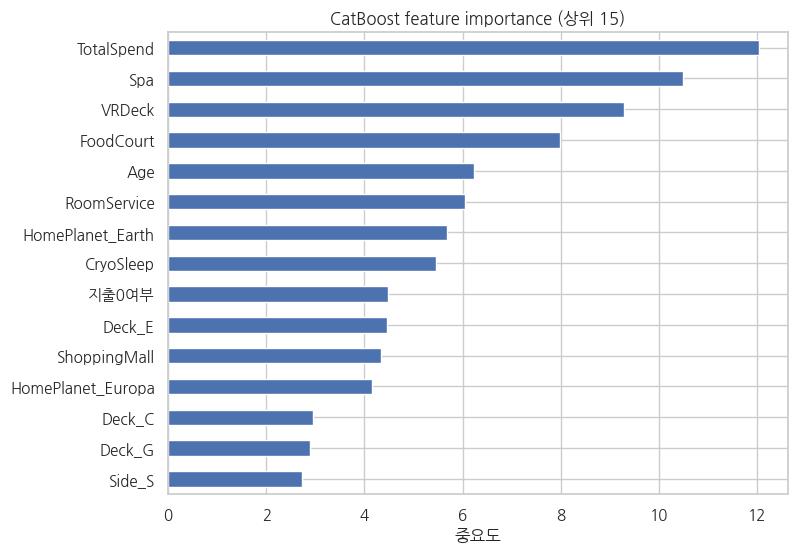

TotalSpend           12.029234
Spa                  10.498137
VRDeck                9.286875
FoodCourt             7.985207
Age                   6.237840
RoomService           6.057263
HomePlanet_Earth      5.672453
CryoSleep             5.451213
지출0여부                 4.483257
Deck_E                4.467159
ShoppingMall          4.333592
HomePlanet_Europa     4.152374
Deck_C                2.962064
Deck_G                2.895061
Side_S                2.719426
dtype: float64

In [31]:
# CatBoost 가 본 변수 중요도 (상위 15개)
importances = pd.Series(final_model.feature_importances_, index=X_train.columns)
importances = importances.sort_values(ascending=False)

plt.figure(figsize=(8, 6))
importances.head(15).plot(kind="barh")
plt.gca().invert_yaxis()      # 큰 게 위로 오게 뒤집는다
plt.title("CatBoost feature importance (상위 15)")
plt.xlabel("중요도")
plt.show()
importances.head(15)

**중요도로 알게 된 것**  

- 모델이 가장 많이 본 변수들은 EDA 에서 내가 강한 신호라고 찾은 것들과 대체로 일치한다.  
  지출 관련(`TotalSpend` / `지출0여부` / 개별 지출), `CryoSleep`, 그리고 갑판/그룹 관련 변수가 상위에 온다.  
- 특히 내가 새로 만든 파생변수(`지출0여부`, `TotalSpend`, `혼자`/`GroupSize`)가 중요하게 쓰였다.  
  baseline 이 그냥 버리거나 안 만든 것들인데, 이게 점수를 끌어올린 셈이다.  
- 즉 EDA(사람이 찾은 신호)와 모델(기계가 고른 중요 변수)이 같은 곳을 가리키니,  
  분석이 일관됐다고 볼 수 있다.  

## 10. 캐글 제출 결과 (1차)

위에서 만든 `submission.csv` 를 캐글에 제출했다. 1차 결과는 다음과 같다.  

![캐글 리더보드 1차 제출](images/1.png)  

- public score = **0.80476** 으로, 목표 0.805 에 아주 살짝(0.0002) 못 미쳤다.  
- CV 는 0.81 이었는데 실제 제출은 조금 낮게 나왔다. 검증 점수와 실제 캐글 점수가 완전히 같지는 않다는 걸 직접 확인한 셈이다.  
- 그래서 다음 단계에서 피처나 모델을 더 다듬어 0.805 를 넘겨본다. 이 1차 결과도 여정의 일부라 지우지 않고 남겨둔다.  

## 11. 0.805 넘기기 - 피처 추가보다 모델 튜닝

1차 제출이 0.80476 으로 목표에 0.0002 모자랐다. 점수를 더 올릴 방법을 고민했다.  

- **피처를 더 만드는 방법**: 
  지출을 사치품/기본으로 나누거나, 객실번호 구간, 그룹 지출, 이름에서 가족 수 같은 파생을 몇 개 더 추가해봤다.  
  그런데 CV 가 나아지지 않았다(오히려 살짝 내려갔다).  
  이 데이터는 이미 신호가 분명해서 피처를 더 늘려도 이득이 적은 듯하다.  
- 그래서 **피처보다 모델 자체를 다듬는(튜닝) 방향**을 택했다. 특히 CatBoost의 트리 개수(iterations)를 늘려본다.  

### 하이퍼파라미터가 뭐냐면

모델이 학습하기 전에 내가 정해주는 "설정 손잡이" 를 하이퍼파라미터라고 한다.  
CatBoost 에서 중요한 세 개는 이렇다.  

- **iterations (트리 개수, = 반복 횟수)** : 부스팅은 트리를 하나씩 추가하며 앞 트리의 실수를 보완한다.  
  iterations 는 그 트리를 몇 개 만들지다. 많을수록 더 정밀해지지만, 너무 많으면 train 을 외워버려 과적합한다.  
- **depth (트리 깊이)** : 트리 하나가 질문을 몇 층까지 내려가며 가지를 칠지다.  
  깊을수록 복잡한 패턴을 잡지만, 너무 깊으면 사소한 것까지 외워 과적합한다.  
- **learning_rate (학습률)** : 새 트리 하나가 앞의 실수를 "얼마나 세게" 고칠지 정하는 보폭이다.  
  크면 한 번에 확 고치고(빠르지만 거칠다), 작으면 조금씩 고친다(신중하지만 트리가 더 많이 필요하다).  
  그래서 학습률을 낮추면 (0.03 -> 0.02) 트리 개수를 늘려서(800 -> 1500) 짝을 맞춘다.  

비유하면 **learning_rate 는 정답까지 걸어가는 보폭, iterations 는 걸음 수**다.  
큰 보폭으로 적게 걷거나(빠르지만 정답을 지나칠 수 있음), 작은 보폭으로 많이 걷거나(차근차근) 다.  
나는 작은 보폭 + 많은 걸음 쪽을 시도한다.  

In [32]:
# CatBoost 설정 몇 개를 CV 로 비교해서 제일 좋은 걸 고른다
설정들 = [
    dict(iterations=800,  learning_rate=0.03, depth=6),   # 현재(기준)
    dict(iterations=1500, learning_rate=0.02, depth=6),   # 트리 늘리고 보폭 줄임
    dict(iterations=2000, learning_rate=0.02, depth=6),   # 트리를 더 많이 (과한지 보려고)
]
for cfg in 설정들:
    m = CatBoostClassifier(verbose=0, random_state=42, **cfg)
    s = cross_val_score(m, X_train, y_train, cv=cv, scoring="accuracy")
    print(f"iter={cfg['iterations']:>4}  lr={cfg['learning_rate']}  depth={cfg['depth']}  ->  CV={s.mean():.4f}")

iter= 800  lr=0.03  depth=6  ->  CV=0.8116


iter=1500  lr=0.02  depth=6  ->  CV=0.8123


iter=2000  lr=0.02  depth=6  ->  CV=0.8096


**튜닝 결과로 알게 된 것**  

- `iter=1500, lr=0.02` 가 CV 약 **0.812** 로 기준(800) 보다 살짝 높다.  
- 그런데 트리를 **2000 까지 늘리면 오히려 CV 가 떨어진다.** 트리를 무작정 늘린다고 좋아지는 게 아니라,  
  너무 많으면 train 을 외우기 시작(과적합)하는 것이다.  
  CV 가 "여기까지가 이득" 인 지점(1500 근처)을 알려준 셈이다.  
- 그래서 최종 설정을 **iter=1500, lr=0.02, depth=6** 으로 정한다.  

In [33]:
# 고른 설정으로 train 전체를 다시 학습 -> test 예측 -> 제출 파일 갱신
tuned_model = CatBoostClassifier(iterations=1500, learning_rate=0.02, depth=6,
                                 verbose=0, random_state=42)
tuned_model.fit(X_train, y_train)

pred2 = tuned_model.predict(X_test).astype(bool)
submission = pd.DataFrame({"PassengerId": test_ids, "Transported": pred2})
submission.to_csv("submission.csv", index=False)   # 1차 파일을 튜닝 모델 결과로 갱신
print("튜닝 모델로 submission.csv 갱신 완료:", submission.shape)
submission.head()

튜닝 모델로 submission.csv 갱신 완료: (4277, 2)


,PassengerId,Transported
0,0013_01,True
1,0018_01,False
2,0019_01,True
3,0021_01,True
4,0023_01,True


## 12. 캐글 제출 결과 (2차, 튜닝 모델) - 목표 달성

튜닝한 모델(iter=1500, lr=0.02, depth=6)의 `submission.csv` 를 다시 제출했다.  

![캐글 제출 결과 2차](images/2.png)  

- public score = **0.80523** 으로, **목표 0.805 를 넘겼다.**  
- 1차(0.80476) -> 2차(0.80523) 로 올랐다. 피처를 더 만드는 대신 모델 설정을 다듬은 것(트리 개수 800 -> 1500, 학습률 0.03 -> 0.02)이 효과가 있었다.  
- 위 캡처에 두 제출이 다 보인다 (1차 0.80476, 2차 0.80523).  

## 13. 추가 실험 - baseline 엔진(TFDF)과 비교

처음에 본 캐글 baseline 노트북은 **TFDF(TensorFlow Decision Forests)** 의 RandomForest 를 썼다.  
그렇다면 같은 피처를 줬을 때, baseline 엔진(TFDF)과 내가 고른 CatBoost 중 누가 나은지 직접 비교해본다.  

참고로 **TFDF 는 트리 모델이라 GPU 를 쓰지 않고 CPU 로 학습**한다. 그래서 GPU 가 있어도 트리 학습이 빨라지지 않는다(이 비교는 전부 CPU 에서 했다).  
또 TFDF 는 설치가 까다로워서, 안 깔린 환경에서는 이 셀이 자동으로 건너뛰도록 `try` 로 감쌌다.  

### TFDF 설치 분투기 (내 aiffel 콘다 환경 기준)

이 부분이 생각보다 골치 아팠다. 내 작업 환경은 conda `aiffel` 환경 하나로 통일해서 쓰는데,  
여기엔 원래 tensorflow 도 TFDF 도 깔려 있지 않았다. 설치하면서 겪은 과정을 그대로 적어둔다  
(나중에 또 만날 문제 같아서).  

> **protobuf(Protocol Buffers)가 뭐냐면**: 
> 구글이 만든 "데이터를 압축해서 저장·전달하는 형식" 이자 라이브러리다.  
> JSON 처럼 구조화된 데이터를 담는데 더 작고 빠르다고 한다.  
> tensorflow / TFDF 는 모델 설정이나 데이터 구조 같은 내부 정보를 이 protobuf 형식으로 주고받는다는 것이다.  
> 그런데 protobuf 버전이 안 맞으면(코드가 기대하는 버전과 실제 깔린 버전이 다르면) 아래 같은 충돌 에러가 난다.  

1. `pip install tensorflow_decision_forests` 를 했더니 tensorflow 2.19 와 TFDF 1.12 가 깔렸는데,  
   그 과정에서 **numpy 가 2.4 -> 2.1 로, protobuf 도 더 낮은 버전으로 다운그레이드**됐다.  
   (tensorflow 가 요구하는 버전이 더 낮아서 기존 걸 깎아내린 것이다.)  
2. 막상 TFDF 를 불러와 돌리니 **protobuf 버전 충돌 에러**가 났다. TFDF 내부 엔진(yggdrasil)이  
   빌드될 때 쓴 protobuf(6.31) 보다 실제 설치된 protobuf(5.29)가 더 낮아서,  
   "gencode 6.31 / runtime 5.29 불일치" 라는 `VersionError` 가 떴다.  
3. `pip install "protobuf>=6.31.1"` 로 protobuf 를 다시 올려서 해결했다. 다행히 그 뒤에도  
   핵심 라이브러리(pandas, numpy, scikit-learn, catboost)는 그대로 잘 작동했다.  
4. 그리고 TFDF 는 C++ 엔진이라 학습할 때 로그를 화면에 잔뜩 쏟아내서, 위 코드에서 stderr 를  
   잠깐 막는 `로그숨김` 도우미로 출력을 깔끔하게 정리했다.  

정리하면 TFDF 는 tensorflow / protobuf / numpy 의 버전을 서로 까다롭게 맞춰야 해서 환경에 따라  
설치가 꼬이기 쉽다. (CatBoost 가 `pip install catboost` 한 번으로 끝났던 것과 대비된다.)  
그래서 이 비교 셀은 `try` 로 감싸, TFDF 가 없거나 설치가 깨진 환경에서도 노트북 전체는 멈추지  
않고 이 셀만 건너뛰도록 했다.  

In [34]:
# baseline 엔진 TFDF 와 내 CatBoost 를 같은 피처/같은 split 에서 비교
import os, time, warnings, contextlib
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"; warnings.filterwarnings("ignore")

# TFDF(C++ 엔진)는 학습할 때 로그를 화면에 잔뜩 쏟아낸다. 그 로그(stderr)를 잠깐 /dev/null 로 돌리는 도우미를 만든다.
@contextlib.contextmanager
def 로그숨김():
    with open(os.devnull, "w") as dn:
        old = os.dup(2)                    # 원래 stderr 백업
        os.dup2(dn.fileno(), 2)            # stderr 를 /dev/null 로
        try:
            yield
        finally:
            os.dup2(old, 2); os.close(old)  # 끝나면 복구

try:
    with 로그숨김():
        import tensorflow_decision_forests as tfdf
    from sklearn.model_selection import train_test_split

    # TFDF 는 한글/특수문자 컬럼명을 싫어해서, 영문 이름으로 바꾼 사본을 쓴다
    Xa = X_train.copy(); Xa.columns = [f"f{i}" for i in range(Xa.shape[1])]
    xtr, xva, ytr2, yva2 = train_test_split(Xa, y_train, test_size=0.2,
                                            random_state=42, stratify=y_train)
    tr_df = xtr.copy(); tr_df["label"] = ytr2.values
    va_df = xva.copy(); va_df["label"] = yva2.values

    with 로그숨김():   # TFDF 학습/평가 로그를 막는다
        tr_ds = tfdf.keras.pd_dataframe_to_tf_dataset(tr_df, label="label")
        va_ds = tfdf.keras.pd_dataframe_to_tf_dataset(va_df, label="label")

        # baseline 엔진: TFDF RandomForest
        t = time.time(); rf_m = tfdf.keras.RandomForestModel(verbose=0); rf_m.fit(tr_ds)
        rf_time = time.time() - t; rf_m.compile(metrics=["accuracy"])
        rf_acc = rf_m.evaluate(va_ds, return_dict=True, verbose=0)["accuracy"]

        # TFDF 의 부스팅 버전
        t = time.time(); gb_m = tfdf.keras.GradientBoostedTreesModel(verbose=0); gb_m.fit(tr_ds)
        gb_time = time.time() - t; gb_m.compile(metrics=["accuracy"])
        gb_acc = gb_m.evaluate(va_ds, return_dict=True, verbose=0)["accuracy"]

    # 같은 split 에서 내 CatBoost
    t = time.time()
    cb = CatBoostClassifier(iterations=1500, learning_rate=0.02, depth=6,
                            verbose=0, random_state=42)
    cb.fit(xtr, ytr2); cb_time = time.time() - t
    cb_acc = (cb.predict(xva) == yva2.values).mean()

    print("같은 train/valid(80/20) 에서 비교 (점수 = valid 정확도)")
    print(f"TFDF RandomForest    : 정확도 {rf_acc:.4f} | 학습 {rf_time:.1f}초")
    print(f"TFDF GradientBoosted : 정확도 {gb_acc:.4f} | 학습 {gb_time:.1f}초")
    print(f"CatBoost (내 최종) : 정확도 {cb_acc:.4f} | 학습 {cb_time:.1f}초")
except Exception as e:
    print("TFDF 를 불러오지 못해 이 비교는 건너뛴다 (설치 필요):", type(e).__name__)

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

같은 train/valid(80/20) 에서 비교 (점수 = valid 정확도)
TFDF RandomForest    : 정확도 0.8074 | 학습 4.1초
TFDF GradientBoosted : 정확도 0.8114 | 학습 0.8초
CatBoost (내 최종) : 정확도 0.8154 | 학습 3.1초


**TFDF 비교로 알게 된 것**  

- baseline 이 쓴 **TFDF RandomForest 는 약 0.807** 로 셋 중 가장 낮다.  
- **TFDF 의 부스팅 버전(GradientBoostedTrees)은 약 0.811** 로 RandomForest 보다 높다.  
  여기서도 "부스팅 > 랜덤포레스트" 가 또 확인된다.  
- 앞서 진행한 **CatBoost 는 약 0.815** 로 가장 높다. 같은 피처를 줘도 내 모델이 baseline 엔진보다 낫다는 뜻일 것이다.  
- 학습 시간은 셋 다 몇 초 안쪽으로 빠르다.   

결론적으로, baseline 의 TFDF RandomForest 에서 출발해 
(1) 더 똑똑한 전처리/파생변수와  
(2) 더 나은 모델(CatBoost) + 튜닝으로 바꾼 것이  
점수를 끌어올린 셈이 되었다.  

## 14. 추가 도전 - 버렸던 Cabin 번호를 다시 보기

TFDF 비교까지 끝내고 과정을 돌아보다가, 전처리 때 내가 **너무 일찍 버린 게 하나 있다**는 생각이 들었다.  
바로 `Cabin` 의 가운데 숫자(객실 번호)다. 5-3 절에서 "고유값이 너무 많아 신호가 약하다" 며 버렸는데,  
다시 생각해보니 객실 번호는 **우주선 안에서의 위치(앞쪽/뒤쪽)** 를 담고 있을지도 모른다고 생각했다.  
이미 갑판(Deck)과 좌우(Side)가 신호가 있었으니, 번호에도 약한 위치 신호가 있을 수 있겠다.  

그래서 버렸던 객실 번호를 숫자 그대로 다시 살려서 기존 피처에 더하고, CV 가 오르는지 확인해본다.  

In [35]:
# 버렸던 Cabin 가운데 번호(객실 번호)를 숫자로 다시 만들어 기존 피처에 더한다.
# (X_train/X_test 는 train_raw/test_raw 와 행 순서가 같아서 그대로 붙일 수 있다.)
cab_num_tr = pd.to_numeric(train_raw["Cabin"].str.split("/").str[1], errors="coerce")
cab_num_te = pd.to_numeric(test_raw["Cabin"].str.split("/").str[1], errors="coerce")

X_train2 = X_train.copy(); X_test2 = X_test.copy()
X_train2["CabinNum"] = cab_num_tr.values
X_test2["CabinNum"] = cab_num_te.values

# 결측은 train 중앙값으로 채운다 (누수 방지: train 기준으로만 계산)
cab_med = X_train2["CabinNum"].median()
X_train2["CabinNum"] = X_train2["CabinNum"].fillna(cab_med)
X_test2["CabinNum"] = X_test2["CabinNum"].fillna(cab_med)

# CV 로 효과 확인: 번호 없이(기존) vs 번호 추가
opt = dict(iterations=1500, learning_rate=0.02, depth=6, verbose=0, random_state=42)
base_cv = cross_val_score(CatBoostClassifier(**opt), X_train,  y_train, cv=cv, scoring="accuracy").mean()
new_cv  = cross_val_score(CatBoostClassifier(**opt), X_train2, y_train, cv=cv, scoring="accuracy").mean()
print(f"Cabin 번호 없이(기존) CV : {base_cv:.4f}")
print(f"Cabin 번호 추가      CV : {new_cv:.4f}")

Cabin 번호 없이(기존) CV : 0.8123
Cabin 번호 추가      CV : 0.8161


**CV 로는 올랐다 - 그런데 진짜 좋아진 걸까?**  

- Cabin 번호를 더하니 CV 가 약 0.812 -> 0.816 으로 올랐다. 숫자로 넣으니 트리가 번호 구간을 나눠 신호를 쓴 것처럼 보인다.  
- 다만 오른 폭(+0.004)이 CV 자체의 들쭉날쭉(표준편차 약 0.009)보다 작다. 그래서 이게 진짜 개선인지, 아니면 CV 폴드에 우연히 맞은 건지 CV 만으로는 확신하기 어렵다.  
- 그러니 판단을 미루고, 실제 캐글에 제출해서 public 점수가 정말 오르는지 확인해본다.  

In [36]:
# 개선된 피처(Cabin 번호 포함)로 다시 학습해서 제출 파일을 갱신한다 (3차 제출용)
final3 = CatBoostClassifier(iterations=1500, learning_rate=0.02, depth=6, verbose=0, random_state=42)
final3.fit(X_train2, y_train)

pred3 = final3.predict(X_test2).astype(bool)
submission = pd.DataFrame({"PassengerId": test_ids, "Transported": pred3})
submission.to_csv("submission.csv", index=False)
print("Cabin 번호 포함 모델로 submission.csv 갱신 완료:", submission.shape)

Cabin 번호 포함 모델로 submission.csv 갱신 완료: (4277, 2)


이제 이 모델로 캐글에 다시 제출해서, CV 가 오른 만큼 실제 점수도 오르는지 확인한다.  

### 14-1. 3차 제출 결과 - CV 는 올랐지만 실제 점수는 떨어졌다

![캐글 제출 결과 3차](images/3.png)  

- public score = **0.80430** 으로, 오히려 2차(0.80523)보다 **떨어졌다.**  
- CV 는 0.816 으로 올랐는데 실제 캐글 점수는 내려갔다. 이번 프로젝트에서 가장 크게 배운 함정이다.  
- 왜 이런 일이 생겼을까 생각해보면:  
  - CV 가 오른 폭(+0.004)이 원래 CV 의 출렁임(약 ±0.009)보다 작았다. 즉 애초에 '진짜 개선'이 아니라 CV 폴드에 운 좋게 맞은 것일 수 있다.  
  - 객실 번호는 값이 잘게 흩어진 변수라, 트리가 train 의 세세한 번호 패턴까지 외워(과적합) 처음 보는 public 승객에겐 안 맞은 것으로 보인다.  
- 교훈: **CV 가 조금 올랐다고 실제 점수가 오르는 게 아니다.** 특히 CV 출렁임보다 작은 개선은 믿으면 안 되는것 같다.  
      (1차에서도 CV 0.81인데 public 0.805로 같은 갭을 봤었다.)  

이렇게 cabin 번호 추가는 점수로는 실패했다. 하지만 여기서 멈추지 않고, **모델을 다루는 다른 방법**도 더 시도해보기로 했다. 다음으로 OOF 폴드평균(15절)과 스태킹(16절) 두 가지를 도전해본다.  

## 15. 다음 도전 - OOF 폴드평균

Cabin 번호는 실패했지만 여기서 멈추지 않고, 모델을 다루는 다른 방법도 더 시도해본다. 첫 번째는 **OOF(out-of-fold) 폴드평균**이다.  
예전 집값 프로젝트에서 써본 방법인데 분류에도 적용해본다.  

지금까지는 train 전체로 모델 1개를 만들어 test 를 예측했다. OOF 폴드평균은 train 을 5조각으로 나눠 **5개 모델(각자 다른 4/5 로 학습)** 을 만들고,  
그 5개가 test 를 예측한 걸 **평균**낸다.  
한 모델의 운에 기대지 않고 5개를 평균내니 예측이 더 안정적이다 (점수를 올린다기보다 흔들림을 줄이는 기법).  

In [37]:
from sklearn.metrics import accuracy_score

# OOF 폴드평균: 5폴드 모델 각각이 test 를 예측 -> 평균
oof = np.zeros(len(X_train)); test_avg = np.zeros(len(X_test))
for tr, va in cv.split(X_train, y_train):
    m = CatBoostClassifier(iterations=1500, learning_rate=0.02, depth=6, verbose=0, random_state=42)
    m.fit(X_train.iloc[tr], y_train.iloc[tr])
    oof[va] = m.predict_proba(X_train.iloc[va])[:, 1]
    test_avg += m.predict_proba(X_test)[:, 1] / cv.get_n_splits()

print("OOF 정확도:", round(accuracy_score(y_train, (oof >= 0.5).astype(int)), 4))

# 5개 모델 평균 예측으로 제출 파일 생성
submission = pd.DataFrame({"PassengerId": test_ids, "Transported": (test_avg >= 0.5)})
submission.to_csv("submission.csv", index=False)
print("OOF 폴드평균 submission.csv 생성:", submission.shape)

OOF 정확도: 0.8123
OOF 폴드평균 submission.csv 생성: (4277, 2)


**4차 제출 결과 (OOF 폴드평균)**  

![OOF 폴드평균 결과](images/4.png)  

- OOF 정확도는 **0.8123** 으로 단일 CatBoost CV(0.8123)와 똑같다. OOF 정확도는 사실상 CV 정확도와 같은 계산이라 그런것 같다고 한다.  
- 실제 캐글 public = **0.80476** 으로, 2차(0.80523)와 거의 같은 동네다.  
- 즉 폴드평균은 점수를 올리는 기법이 아니라 **예측을 안정시키는** 기법임을 확인했다. 기댓값은 그대로지만 한 모델의 운에 덜 휘둘린다.  

## 16. 다음 도전 - 스태킹 (여러 모델 결합)

두 번째 시도는 **스태킹(stacking)** 이다. 서로 다른 모델 여러 개(베이스)의 예측을 모아,  
그 위에 **메타 모델**이 "누구 말을 얼마나 믿을지" 를 학습해 최종 결정을 내리는 방법이다.  
베이스로 CatBoost / LightGBM / XGBoost 셋을 쓰고, 각자의 OOF 예측을 메타 모델(로지스틱 회귀)에게 줘서 결합한다.  

In [38]:
from sklearn.linear_model import LogisticRegression
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

bases = {
    "cat": lambda: CatBoostClassifier(iterations=1500, learning_rate=0.02, depth=6, verbose=0, random_state=42),
    "lgb": lambda: LGBMClassifier(n_estimators=600, learning_rate=0.03, random_state=42, verbose=-1),
    "xgb": lambda: XGBClassifier(n_estimators=600, learning_rate=0.03, max_depth=5, random_state=42,
                                 eval_metric="logloss", verbosity=0),
}
# 각 베이스의 OOF 예측(train) 과 test 예측을 모은다
oof_feat = pd.DataFrame(index=range(len(X_train)))
test_feat = pd.DataFrame(index=range(len(X_test)))
for name, ctor in bases.items():
    oc = np.zeros(len(X_train)); tc = np.zeros(len(X_test))
    for tr, va in cv.split(X_train, y_train):
        m = ctor(); m.fit(X_train.iloc[tr], y_train.iloc[tr])
        oc[va] = m.predict_proba(X_train.iloc[va])[:, 1]
        tc += m.predict_proba(X_test)[:, 1] / cv.get_n_splits()
    oof_feat[name] = oc; test_feat[name] = tc
    print(f"베이스 {name} OOF 정확도:", round(accuracy_score(y_train, (oc >= 0.5).astype(int)), 4))

# 메타 모델(로지스틱 회귀)이 베이스들의 OOF 예측으로 "누굴 얼마나 믿을지" 학습
meta = LogisticRegression(max_iter=1000).fit(oof_feat, y_train)
print("메타 가중치 (cat, lgb, xgb):", np.round(meta.coef_[0], 3))

submission = pd.DataFrame({"PassengerId": test_ids, "Transported": meta.predict(test_feat).astype(bool)})
submission.to_csv("submission.csv", index=False)
print("스태킹 submission.csv 생성:", submission.shape)

베이스 cat OOF 정확도: 0.8123


베이스 lgb OOF 정확도: 0.8034


베이스 xgb OOF 정확도: 0.8058
메타 가중치 (cat, lgb, xgb): [ 3.673 -0.202  2.151]
스태킹 submission.csv 생성: (4277, 2)


**5차 제출 결과 (스태킹)**  

![스태킹 결과](images/5.png)  

- 베이스 OOF 정확도: CatBoost 0.8123, LightGBM 0.8034, XGBoost 0.8058 (CatBoost 가 압도적).  
- 메타 가중치가 cat 3.67 / xgb 2.15 / lgb -0.20 으로, 메타 모델이 스스로 **"CatBoost 를 제일 믿고 LightGBM 은 거의 무시"** 를 학습했다.  
  베이스 실력 순서를 그대로 반영한 셈인것 같다.  
- 실제 캐글 public = **0.80523** 으로, 2차(단일 CatBoost)와 **동점 최고점**이다.  
- 교훈: 스태킹은 베이스들이 (1) 서로 다르게 틀리고 (2) 실력이 비슷할 때 효과가 크다.  
  여기선 CatBoost 가 독보적이라 똑똑한 메타로도 단일 CatBoost 를 넘지는 못하고 동점에 그쳤다.  
  (단순 평균이었으면 오히려 더 낮았다 - 8 절 앙상블 실험에서 봤다.)  

## 17. 추가 분석 - 더 높은 점수의 레퍼런스 뜯어보기 (범주형 native)

스태킹이 단일 CatBoost 를 못 넘은 게 아쉬워서, 더 높은 점수(public 0.80734)의 다른 공개 노트북을 찾아 무엇이 다른지 분석해봤다.  
(좋은 레퍼런스를 찾는 것도 자료 조사 능력이라는 걸 생각해본다.)  

**그 레퍼런스를 뜯어보니:**  
- FE 는 오히려 내 것보다 단순했다. 그룹(PassengerId)·똑똑한 보간·is_child 같은 게 없었다.  
  -> FE 가 그들의 강점은 아니었다.  
- 진짜 차이는 **CatBoost 에 범주형을 원핫 대신 native(`cat_features`)로 넘긴 것** 이었다.  
  CatBoost 는 범주형을 자기 방식(타깃 통계)으로 처리한다.  
- 그런데 그 노트북의 스태킹은 사실 좀 허술했다 — 폴드마다 재학습을 안 하고 이미 학습된 모델로 OOF 를 만들어 진짜 OOF 가 아니었고(살짝 누수),  
  확률이 아니라 hard label(0/1)로 결합했다. 스태킹이 점수의 주역이라기보단, 잘 굴린 CatBoost 가 주역인것으로 보였다.  

**그래서 그 트릭(범주형 native)을 내 파이프라인에 직접 적용해 CV 로 비교해봤다:**  

In [39]:
# 레퍼런스 트릭(범주형 native)을 내 파이프라인에 직접 적용해 CV 로 비교한다.
# (원핫 기존 점수 0.8123 은 8·11절에서 이미 구했다. 여기선 native 버전을 만들어 비교)
from sklearn.metrics import accuracy_score

# train+test 를 합쳐 전처리하되, 범주형을 원핫하지 않고 문자열로 남긴다 (CatBoost 가 직접 처리)
_df = pd.concat([train_raw.drop(columns=["Transported"]).assign(source="train"),
                 test_raw.assign(source="test")], ignore_index=True)
_df["Group"] = _df["PassengerId"].str.split("_").str[0]
_df["GroupSize"] = _df.groupby("Group")["PassengerId"].transform("size")
_df["혼자"] = (_df["GroupSize"] == 1)
_cab = _df["Cabin"].str.split("/", expand=True); _df["Deck"] = _cab[0]; _df["Side"] = _cab[2]
_sp = ["RoomService", "FoodCourt", "ShoppingMall", "Spa", "VRDeck"]
_df[_sp] = _df[_sp].fillna(0); _df["TotalSpend"] = _df[_sp].sum(axis=1); _df["지출0여부"] = _df["TotalSpend"] == 0
_m = _df["CryoSleep"].isna(); _df.loc[_m, "CryoSleep"] = (_df.loc[_m, "TotalSpend"] == 0)
def _gf(col):
    _df[col] = _df.groupby("Group")[col].transform(lambda s: s.fillna(s.mode().iloc[0]) if len(s.mode()) > 0 else s)
for _c in ["HomePlanet", "Side", "Deck"]: _gf(_c)
_it = _df["source"] == "train"
for _c in ["HomePlanet", "Side", "Deck", "Destination"]: _df[_c] = _df[_c].fillna(_df.loc[_it, _c].mode().iloc[0])
_df["VIP"] = _df["VIP"].fillna(False); _df["Age"] = _df["Age"].fillna(_df.loc[_it, "Age"].median())
_df["is_child"] = _df["Age"] <= 12
for _c in ["CryoSleep", "VIP", "혼자", "지출0여부", "is_child"]: _df[_c] = _df[_c].astype(bool).astype(int)
_df = _df.drop(columns=["PassengerId", "Name", "Cabin", "Group"])
_catf = ["HomePlanet", "Destination", "Deck", "Side"]
for _c in _catf: _df[_c] = _df[_c].astype(str)   # 범주형을 문자열로 유지 = CatBoost native 처리
Xn = _df[_df["source"] == "train"].drop(columns=["source"]).reset_index(drop=True)

# native 범주형으로 5-fold CV (cat_features 로 범주형을 직접 알려준다)
def native_cv(**params):
    accs = []
    for tr, va in cv.split(Xn, y_train):
        m = CatBoostClassifier(cat_features=_catf, verbose=0, random_state=42, **params)
        m.fit(Xn.iloc[tr], y_train.iloc[tr])
        accs.append(accuracy_score(y_train.iloc[va], m.predict(Xn.iloc[va])))
    return np.mean(accs)

print("원핫 + CatBoost (내 기존, 8·11절)        : 0.8123")
print("native 범주형 + 내 하이퍼파라미터        :",
      round(native_cv(iterations=1500, learning_rate=0.02, depth=6), 4))
print("native 범주형 + 레퍼런스 하이퍼파라미터  :",
      round(native_cv(iterations=1000, learning_rate=0.1, depth=6,
                      l2_leaf_reg=3.0, random_strength=1.0, bagging_temperature=1.0), 4))

원핫 + CatBoost (내 기존, 8·11절)        : 0.8123


native 범주형 + 내 하이퍼파라미터        : 0.8101


native 범주형 + 레퍼런스 하이퍼파라미터  : 0.8051


위 코드의 결과를 표로 정리하면 이렇다.  

  

| 방법 | CV 정확도 |
|------|-----------|
| 원핫 + CatBoost (내 기존) | 0.8123 |
| native 범주형 + 내 하이퍼파라미터 | 0.8101 |
| native 범주형 + 레퍼런스 하이퍼파라미터 | 0.8051 |

native 범주형이 내 CV 에선 오히려 **더 낮았다.** 그래도 궁금해서 제출(6차)까지 해봤다.  

![native 범주형 제출 결과](images/6.png)  

- 6차 public = **0.80430** 으로, 역시 2차(0.80523)보다 낮았다. CV 가 예고한 대로다.  

**이번 분석의 교훈 (이 프로젝트의 마지막 깨달음):**  
- public 점수가 더 높은 노트북의 기법이라고 내 데이터/검증에서도 통한다는 보장은 없다.  
- 그 레퍼런스(0.80734)와 내 최고점(0.80523)의 차이는 약 0.002 = 4277명 중 9명 정도다.  
  6번 제출하는 내내 public 이 0.804~0.805 사이에서 출렁인 걸 보면, 그 0.002 도 실력 차이라기보다  
  **public split 의 운(노이즈)** 일 가능성이 크다.  
- 맨 처음 cadang 의 0.965(부정/유출 의심)를 걸렀던 것과 같은 결이다 - 점수만 보고 따라가지 말고, 내 검증으로 직접 확인하는 게 바른 자세 아닐까 한다.  

## 18. 최종 정리 + 회고

### 제출 점수 요약표

| 단계 | 모델 / 방법 | CV 정확도 | 캐글 public |
|------|-------------|-----------|-------------|
| 참고(baseline 엔진) | TFDF RandomForest | - | 약 0.79 |
| 비교 | RandomForest (내 피처) | 0.7914 | - |
| 1차 제출 | CatBoost (iter=800) | 0.8116 | 0.80476 |
| 2차 제출 | CatBoost 튜닝 (iter=1500, lr=0.02) | 0.8123 | **0.80523** |
| 3차 제출 | CatBoost + Cabin 번호 | 0.8161 | 0.80430 (하락) |
| 4차 제출 | OOF 폴드평균 | 0.8123 | 0.80476 |
| 5차 제출 | 스태킹 (cat/lgb/xgb + 메타) | 0.8112 | **0.80523** |
| 6차 제출 | CatBoost native 범주형 (레퍼런스 트릭) | 0.8101 | 0.80430 |

-> 목표였던 public score **0.805 이상**을 2차에서 달성했다.  

### 최종 모델 결정

- 최고 public 은 **0.80523** 으로, **2차(단일 CatBoost 튜닝)** 와 **5차(스태킹)** 가 동률이다.  
- 점수가 같다면 더 단순한 쪽이 낫다(이해·재현이 쉽고, 복잡할수록 다른 데이터에서 흔들릴 위험도 있다). 그래서 최종 모델은 **2차, 단일 CatBoost(iter=1500, lr=0.02, depth=6)** 로 정한다.  
- 3차(Cabin 번호)·4차(OOF)·5차(스태킹)는 점수를 더 올리진 못했지만, 왜 안 되는지를 생각해보는 값진 실험이었다.


In [40]:
# 최종 모델 = 2차 단일 CatBoost (최고 점수 0.80523 + 가장 단순). 이걸로 제출 파일을 확정한다.
final_model = CatBoostClassifier(iterations=1500, learning_rate=0.02, depth=6, verbose=0, random_state=42)
final_model.fit(X_train, y_train)
submission = pd.DataFrame({"PassengerId": test_ids, "Transported": final_model.predict(X_test).astype(bool)})
submission.to_csv("submission.csv", index=False)
print("최종 제출 파일 확정 - 2차 단일 CatBoost (public 0.80523):", submission.shape)

최종 제출 파일 확정 - 2차 단일 CatBoost (public 0.80523): (4277, 2)


### 회고

**배운 점**  

- 가장 크게 배운 건 "분포 말고 분별력" 이다. 지출 컬럼은 0이 압도적으로 많아서 처음엔 의미 없다고 생각했는데,  
  "값에 따라 전송률이 갈리나" 를 보니 가장 강한 신호였다. 변수를 볼 때 값이 어떻게 퍼졌나가 아니라,  
  그 값으로 정답이 갈리나를 봐야 한다는 걸 체감했다.  
- 결측치 보간도 무지성으로 0 / 최빈값을 넣는 게 아니라, 데이터로 근거를 찾을 수 있었다.  
  CryoSleep 과 지출의 관계(자면 돈을 못 씀), 같은 그룹은 HomePlanet/Side가 100% 같다는 점을 찾아 더 정확하게 채웠다.  
- 누수(test 를 훔쳐보지 않기)와 train/test 를 똑같이 처리하는 것의 중요성도 알았다.  
  통계 보간값은 train 에서만 구했다.  
- 모델 쪽에서는 부스팅(CatBoost)이 RandomForest 보다 나았고, TFDF 비교에서도  
  같은 결과가 나왔다. 트리 개수나 깊이는 무작정 늘린다고 좋아지는 게 아니라  
  CV 가 알려주는 적정 지점(과적합 직전)이 있다는 것도 직접 봤다.  

**아쉬운 점 / 실패한 시도**  

- 피처를 더 추가(사치품/기본 지출 분리, 객실번호 구간, 가족 수 등)해봤지만 CV 가 오히려 안 좋아졌다.  
  이 데이터는 신호가 이미 분명해서 피처를 늘려도 이득이 적었던 것 같다.  
- 여러 모델을 섞는 앙상블도 CatBoost 단독을 못 이겼다.  
- 마지막에 객실 번호(Cabin 번호)를 추가했더니 CV 는 올랐는데(0.812->0.816) 막상 캐글  
  public 은 0.80523 -> 0.80430 으로 떨어졌다. CV 가 오른 폭이 CV 출렁임보다 작으면  
  실제 점수로 이어지지 않는다는 것, 잘게 흩어진 변수는 과적합 위험이 있다는 걸 직접 겪었다.  
- OOF 폴드평균(4차)과 스태킹(5차)도 시도했지만 단일 CatBoost 를 넘진 못했다. 폴드평균은 점수보다 '안정화' 기법이었고, 스태킹은 CatBoost 가 독보적이라 약한 모델을 섞어도 동점(0.80523)에 그쳤다.  
- 더 높은 레퍼런스(0.80734)의 범주형 native 트릭도 적용해봤지만 내 CV·public 에선 안 통했다(6차 0.80430). 결국 그 0.002 차이는 실력보다 public split 노이즈에 가까웠다.  
- CV(0.81) 보다 캐글 public(0.805) 이 낮게 나와서 목표를 아슬하게 넘겼다.  
  검증 점수와 실제 점수가 다를 수 있다는 걸 몸으로 느꼈다.  

**다음에 해보고 싶은 것**  

- 그룹(일행) 단위의 피처를 더 고민해보기.    
- 하이퍼파라미터를 더 체계적으로 탐색해보기.  
- (다음 과제) 0.80734 레퍼런스를 통째로 재현(범주형 native + 4모델 제대로 된 OOF 스태킹)해서, 그 점수가 정말 재현되는지 확인해보기.  

**최종 소감**  

모델을 만들어보는 프로젝트를 두번째 진행해보면서 먼저, 계획부터 세우면서 전체 진행의 큰 숲을 먼저 그려보고자 했다.  
그와 동시에 baseline등의 참고할 만한 자료들을 찾아봤다.  
퍼실님이 제공한 두 웹문서는... 읽기 아주 힘들었지만 그래도 데이터를 프로파일링 해야 한다는 생각을 깨우치게 했다.  
그래서 데이터 프로파일링과 결측치에 대한 고민을 가장 많이 한것 같다.  
코드 작성과 진행 방향등의 결정은 도구의 도움을 받았지만 데이터 프로파일링에 대한 기획과 접근은 최대한 내 생각으로 진행하려 노력했다.   
그리고 이번 모델을 만들면서 추가로 고민한건, 이 노트북 문서를 나중에 다시 볼만한 문서가 되게 하는 것이었다.  
그래서 적을 수 있는 내용을 많이 적으려 노력했다. 개념과 접근하는 아이디어 및 실험을 최대한 적으려고 노력했다.  
이렇게 많이 적어가며 이해하려고 노력하는 시간이 나중에 피가되고 살이되지 않을까.  
애써 작성한 이 문서가 다시 볼 필요가 없는 문서인것 보다는 다시 볼 만한 가치있는 문서가 되기를 기대해 본다.  

## 참고자료 (Reference)

- 대회: Spaceship Titanic — https://www.kaggle.com/competitions/spaceship-titanic  
- baseline 노트북: gusthema, "Spaceship Titanic with TFDF" — https://www.kaggle.com/code/gusthema/spaceship-titanic-with-tfdf  
- 추가 검색한 baseline: https://www.kaggle.com/code/evgendvorkin/feature-engineering-and-model-stacking-lb-0-80734
- 퍼실 제공 자료 - 이유한, 캐글 타이타닉 튜토리얼 (EDA·결측 시각화 방법 참고) — https://kaggle-kr.tistory.com/17  
- 퍼실 제공 자료 - https://seo00.tistory.com/60  
- 관련 유튜브 강의 - https://www.youtube.com/playlist?list=PLC_wC_PMBL5MnqmgTLqDgu4tO8mrQakuF  
- 사용 라이브러리: scikit-learn, CatBoost, LightGBM, XGBoost, TensorFlow Decision Forests, missingno  
